In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import warnings
from sklearn.exceptions import ConvergenceWarning
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle

In [2]:
df = pd.read_csv("../data/METABRIC_RNA_Mutation.csv")
print(df.shape)

(1904, 693)


/var/folders/2y/hylb1v1n55b2675rzdhyt2b00000gn/T/ipykernel_27283/2091382455.py:1: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/METABRIC_RNA_Mutation.csv")


# Layer 1 - Preprocessing

In [3]:
print(f"Rows (patients): {df.shape[0]}")
print(f"Columns (features): {df.shape[1]}")
print()
print(df.dtypes)

Rows (patients): 1904
Columns (features): 693

patient_id                  int64
age_at_diagnosis          float64
type_of_breast_surgery     object
cancer_type                object
cancer_type_detailed       object
                           ...   
hras_mut                   object
prps2_mut                  object
smarcb1_mut                object
stmn2_mut                  object
siah1_mut                  object
Length: 693, dtype: object


In [4]:
print("Outcome column dtypes:")
print(df[['overall_survival', 'death_from_cancer', 'overall_survival_months']].dtypes)

Outcome column dtypes:
overall_survival             int64
death_from_cancer           object
overall_survival_months    float64
dtype: object


In [5]:
print("overall_survival unique values:")
print(df['overall_survival'].value_counts(dropna=False))

overall_survival unique values:
overall_survival
0    1103
1     801
Name: count, dtype: int64


In [6]:
print("death_from_cancer unique values:")
print(df['death_from_cancer'].value_counts(dropna=False))


death_from_cancer unique values:
death_from_cancer
Living                  801
Died of Disease         622
Died of Other Causes    480
NaN                       1
Name: count, dtype: int64


In [7]:
print("Dtype counts across all columns:")
print(df.dtypes.value_counts())

Dtype counts across all columns:
float64    498
object     190
int64        5
Name: count, dtype: int64


In [4]:
# dropping the 1 row with missing death_from_cancer
df = df.dropna(subset=['death_from_cancer'])
print(f"Rows after dropping missing outcome: {len(df)}")

Rows after dropping missing outcome: 1903


In [5]:
# creating a clean binary event column
# 1 = died from cancer, 0 = censored (living or died of other causes)
# i do this because in our analysis we are only interested in the patients that have died from cancer since we predict cancer survival specifically.
df['event'] = (df['death_from_cancer'] == 'Died of Disease').astype(int)

In [10]:
print(f"\nEvent distribution:")
print(df['event'].value_counts())
print(f"\nEvent rate: {df['event'].mean():.1%}")
print(f"Censoring rate: {1 - df['event'].mean():.1%}")


Event distribution:
event
0    1281
1     622
Name: count, dtype: int64

Event rate: 32.7%
Censoring rate: 67.3%


In [11]:
print(f"\nMissing survival times: {df['overall_survival_months'].isnull().sum()}")
print(f"\nSurvival time range: {df['overall_survival_months'].min():.1f} to {df['overall_survival_months'].max():.1f} months")


Missing survival times: 0

Survival time range: 0.0 to 355.2 months


In [12]:
print(f"Patients with survival time = 0: {(df['overall_survival_months'] == 0).sum()}")
print(f"Patients with survival time < 1 month: {(df['overall_survival_months'] < 1).sum()}")
print()
print(df[df['overall_survival_months'] < 1][['overall_survival_months', 'death_from_cancer', 'event']])

Patients with survival time = 0: 1
Patients with survival time < 1 month: 3

      overall_survival_months death_from_cancer  event
170                  0.000000            Living      0
434                  0.766667            Living      0
1616                 0.100000   Died of Disease      1


In [6]:
# dropping the single patient with survival time = 0
df = df[df['overall_survival_months'] > 0]
print(f"Rows after dropping zero survival time: {len(df)}")

Rows after dropping zero survival time: 1902


## Handling clinical data

In [14]:
# check outcome columns first
print("Outcome columns — missing values:")
print(f"overall_survival_months: {df['overall_survival_months'].isnull().sum()}")
print(f"death_from_cancer:       {df['death_from_cancer'].isnull().sum()}")
print(f"overall_survival:        {df['overall_survival'].isnull().sum()}")
print()

Outcome columns — missing values:
overall_survival_months: 0
death_from_cancer:       0
overall_survival:        0



In [7]:
therapy_cols = [
    'chemotherapy',
    'hormone_therapy',
    'radio_therapy'
]

# patients with NO therapy at all
no_therapy = df[
    (df[therapy_cols] == 0).all(axis=1)
]

print("Patients with no therapy:", len(no_therapy))

Patients with no therapy: 288


In [8]:
df[['cancer_type', 'cancer_type_detailed']].drop_duplicates()

,cancer_type,cancer_type_detailed
0,Breast Cancer,Breast Invasive Ductal Carcinoma
3,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma
9,Breast Cancer,Breast Invasive Lobular Carcinoma
97,Breast Cancer,Breast Invasive Mixed Mucinous Carcinoma
189,Breast Cancer,Breast
206,Breast Cancer,NaN
550,Breast Cancer,Metaplastic Breast Cancer


In [9]:
df['tumor_other_histologic_subtype'].value_counts(dropna=False)

tumor_other_histologic_subtype
Ductal/NST             1452
Mixed                   207
Lobular                 142
Medullary                25
Mucinous                 22
Tubular/ cribriform      21
Other                    17
NaN                      15
Metaplastic               1
Name: count, dtype: int64

In [10]:
pd.crosstab(
    df['cancer_type_detailed'],
    df['tumor_other_histologic_subtype']
)

tumor_other_histologic_subtype,Ductal/NST,Lobular,Medullary,Metaplastic,Mixed,Mucinous,Other,Tubular/ cribriform
cancer_type_detailed,,,,,,,,
Breast,0,0,0,0,0,0,17,0
Breast Invasive Ductal Carcinoma,1452,0,25,0,0,0,0,21
Breast Invasive Lobular Carcinoma,0,142,0,0,0,0,0,0
Breast Invasive Mixed Mucinous Carcinoma,0,0,0,0,0,22,0,0
Breast Mixed Ductal and Lobular Carcinoma,0,0,0,0,207,0,0,0
Metaplastic Breast Cancer,0,0,0,1,0,0,0,0


In [11]:
pd.crosstab(
    df['oncotree_code'],
    df['cancer_type_detailed']
)

cancer_type_detailed,Breast,Breast Invasive Ductal Carcinoma,Breast Invasive Lobular Carcinoma,Breast Invasive Mixed Mucinous Carcinoma,Breast Mixed Ductal and Lobular Carcinoma,Metaplastic Breast Cancer
oncotree_code,,,,,,
BREAST,17,0,0,0,0,0
IDC,0,1498,0,0,0,0
ILC,0,0,142,0,0,0
IMMC,0,0,0,22,0,0
MBC,0,0,0,0,0,1
MDLC,0,0,0,0,207,0


In [12]:
# full clinical columns from data card
clinical_cols = [
    # patient info
    'patient_id',
    'age_at_diagnosis',
    'inferred_menopausal_state',
    'primary_tumor_laterality',
    
    # tumor characteristics
    'cancer_type',
    'cancer_type_detailed',
    'tumor_other_histologic_subtype',
    'cellularity',
    'neoplasm_histologic_grade',
    'tumor_size',
    'tumor_stage',
    'lymph_nodes_examined_positive',
    'nottingham_prognostic_index',
    
    # receptor status
    'er_status',
    'er_status_measured_by_ihc',
    'pr_status',
    'her2_status',
    'her2_status_measured_by_snp6',
    
    # molecular subtypes
    '3-gene_classifier_subtype',
    'pam50_+_claudin-low_subtype',
    'integrative_cluster',
    
    # treatment
    'type_of_breast_surgery',
    'chemotherapy',
    'hormone_therapy',
    'radio_therapy',
    
    # other
    'cohort',
    'oncotree_code',
    'mutation_count'
]

# columns to drop - redundant or derivable from others
drop_cols = [
    'patient_id',
    'cancer_type',               # redundant with cancer_type_detailed
    'er_status_measured_by_ihc', # redundant with er_status
    'her2_status_measured_by_snp6', # redundant with her2_status
    'tumor_other_histologic_subtype', # redundant with cancer_type_detailed
    # I do not know whether I should drop tumor_other_histologic_subtype: go to kaggle dataset data card for explanation
    'oncotree_code', # redundant with cancer_type_detailed
]

# update clinical_cols to exclude dropped ones
clinical_cols = [c for c in clinical_cols if c not in drop_cols]

# check missing values on final clinical cols
missing = df[clinical_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print("Missing values in clinical columns:")
print(missing_df)

Missing values in clinical columns:
                               missing_count  missing_pct
tumor_stage                              500        26.29
3-gene_classifier_subtype                204        10.73
primary_tumor_laterality                 105         5.52
neoplasm_histologic_grade                 71         3.73
cellularity                               54         2.84
mutation_count                            45         2.37
type_of_breast_surgery                    21         1.10
tumor_size                                19         1.00
cancer_type_detailed                      15         0.79
integrative_cluster                        0         0.00
cohort                                     0         0.00
radio_therapy                              0         0.00
hormone_therapy                            0         0.00
chemotherapy                               0         0.00
age_at_diagnosis                           0         0.00
pam50_+_claudin-low_subtype         

In [13]:
df = df.drop(columns=drop_cols)
print(f"Dropped columns: {drop_cols}")
print(f"Remaining columns in df: {df.shape[1]}")

Dropped columns: ['patient_id', 'cancer_type', 'er_status_measured_by_ihc', 'her2_status_measured_by_snp6', 'tumor_other_histologic_subtype', 'oncotree_code']
Remaining columns in df: 688


## Useful visulizations

In [14]:
COLOR_MISSING  = '#C0392B'   # deep red
COLOR_PRESENT  = '#1A7A6E'   # deep teal
COLOR_ACCENT   = '#E67E00'   # deep amber
COLOR_BG       = 'white'
COLOR_CARD     = '#F8F8F8'
COLOR_TEXT     = '#1A1A1A'
COLOR_SUBTEXT  = '#555555'

plt.rcParams.update({
    'figure.facecolor':  COLOR_BG,
    'axes.facecolor':    COLOR_CARD,
    'axes.edgecolor':    '#CCCCCC',
    'axes.labelcolor':   COLOR_TEXT,
    'xtick.color':       COLOR_SUBTEXT,
    'ytick.color':       COLOR_SUBTEXT,
    'text.color':        COLOR_TEXT,
    'grid.color':        '#DDDDDD',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
})
clinical_cols = [
    # demographics
    'age_at_diagnosis',
    'inferred_menopausal_state',
    'primary_tumor_laterality',

    # tumor characteristics
    'cancer_type_detailed',
    'cellularity',
    'neoplasm_histologic_grade',
    'tumor_size',
    'tumor_stage',
    'lymph_nodes_examined_positive',
    'nottingham_prognostic_index',

    # receptor status
    'er_status',
    'pr_status',
    'her2_status',

    # molecular subtype
    '3-gene_classifier_subtype',
    'pam50_+_claudin-low_subtype',
    'integrative_cluster',

    # treatment
    'type_of_breast_surgery',
    'chemotherapy',
    'hormone_therapy',
    'radio_therapy',

    # other clinical/genomic summaries
    'cohort',
    'mutation_count'
]

missing_pct = (
    df[clinical_cols]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_pct_nonzero = missing_pct[missing_pct > 0]

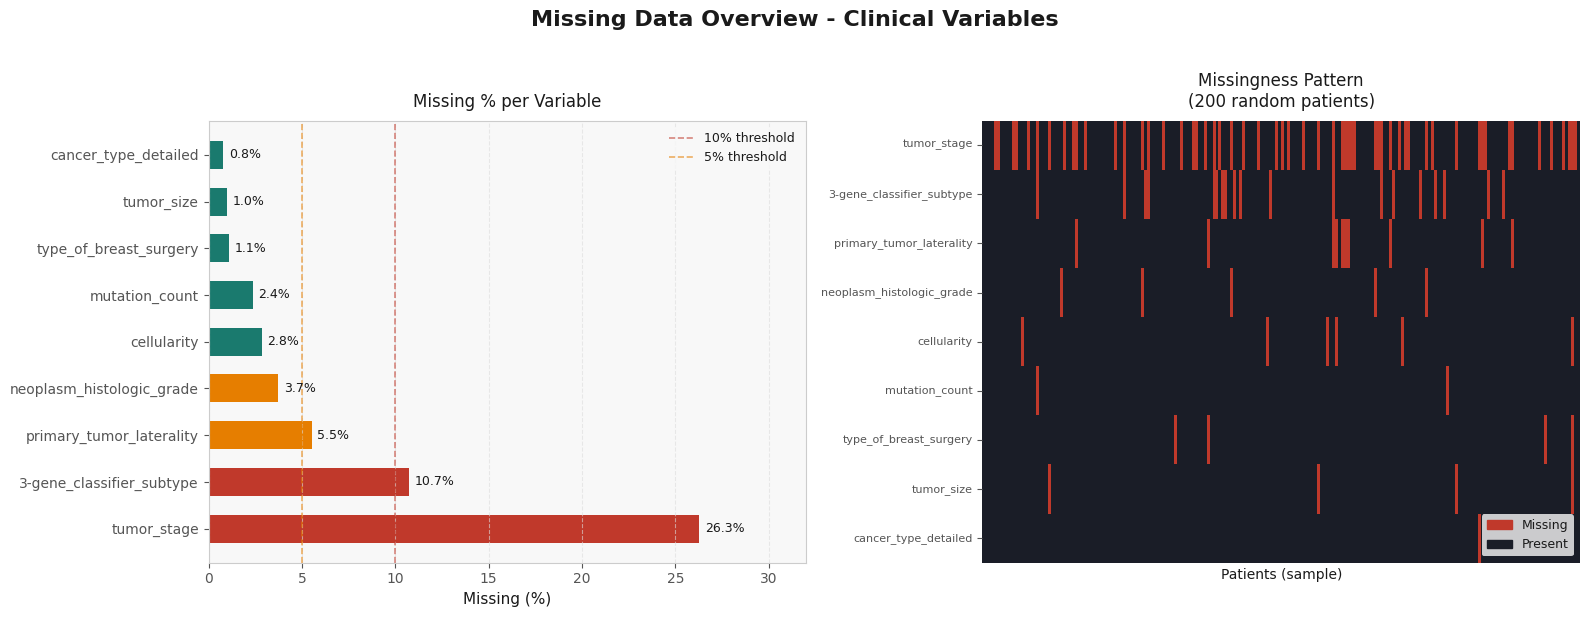

In [15]:
# missing values overview
missing_pct = (df[clinical_cols].isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct_nonzero = missing_pct[missing_pct > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('Missing Data Overview - Clinical Variables', 
             fontsize=16, fontweight='bold', color=COLOR_TEXT, y=1.02)

ax1 = axes[0]
colors = [COLOR_MISSING if p > 10 else COLOR_ACCENT if p > 3 else COLOR_PRESENT 
          for p in missing_pct_nonzero.values]
bars = ax1.barh(missing_pct_nonzero.index, missing_pct_nonzero.values, 
                color=colors, edgecolor='none', height=0.6)
ax1.axvline(x=10, color=COLOR_MISSING, linestyle='--', alpha=0.6, linewidth=1.2, label='10% threshold')
ax1.axvline(x=5,  color=COLOR_ACCENT,  linestyle='--', alpha=0.6, linewidth=1.2, label='5% threshold')
for bar, val in zip(bars, missing_pct_nonzero.values):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, color=COLOR_TEXT)
ax1.set_xlabel('Missing (%)', fontsize=11)
ax1.set_title('Missing % per Variable', fontsize=12, color=COLOR_TEXT, pad=10)
ax1.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax1.grid(axis='x')
ax1.set_xlim(0, 32)

ax2 = axes[1]
missing_matrix = df[clinical_cols].isnull().astype(int)
sample_idx = missing_matrix.sample(min(200, len(missing_matrix)), random_state=42).index
missing_sample = missing_matrix.loc[sample_idx]
missing_sample = missing_sample[missing_pct_nonzero.index]
sns.heatmap(missing_sample.T, 
            cmap=['#1A1D27', COLOR_MISSING],
            cbar=False, ax=ax2,
            xticklabels=False,
            yticklabels=True,
            linewidths=0)
ax2.set_title('Missingness Pattern\n(200 random patients)', fontsize=12, color=COLOR_TEXT, pad=10)
ax2.set_xlabel('Patients (sample)', fontsize=10)
ax2.tick_params(axis='y', labelsize=8)
red_patch  = mpatches.Patch(color=COLOR_MISSING, label='Missing')
gray_patch = mpatches.Patch(color='#1A1D27',     label='Present')
ax2.legend(handles=[red_patch, gray_patch], fontsize=9, 
           facecolor=COLOR_CARD, edgecolor='none', loc='lower right')

plt.tight_layout()
plt.show()

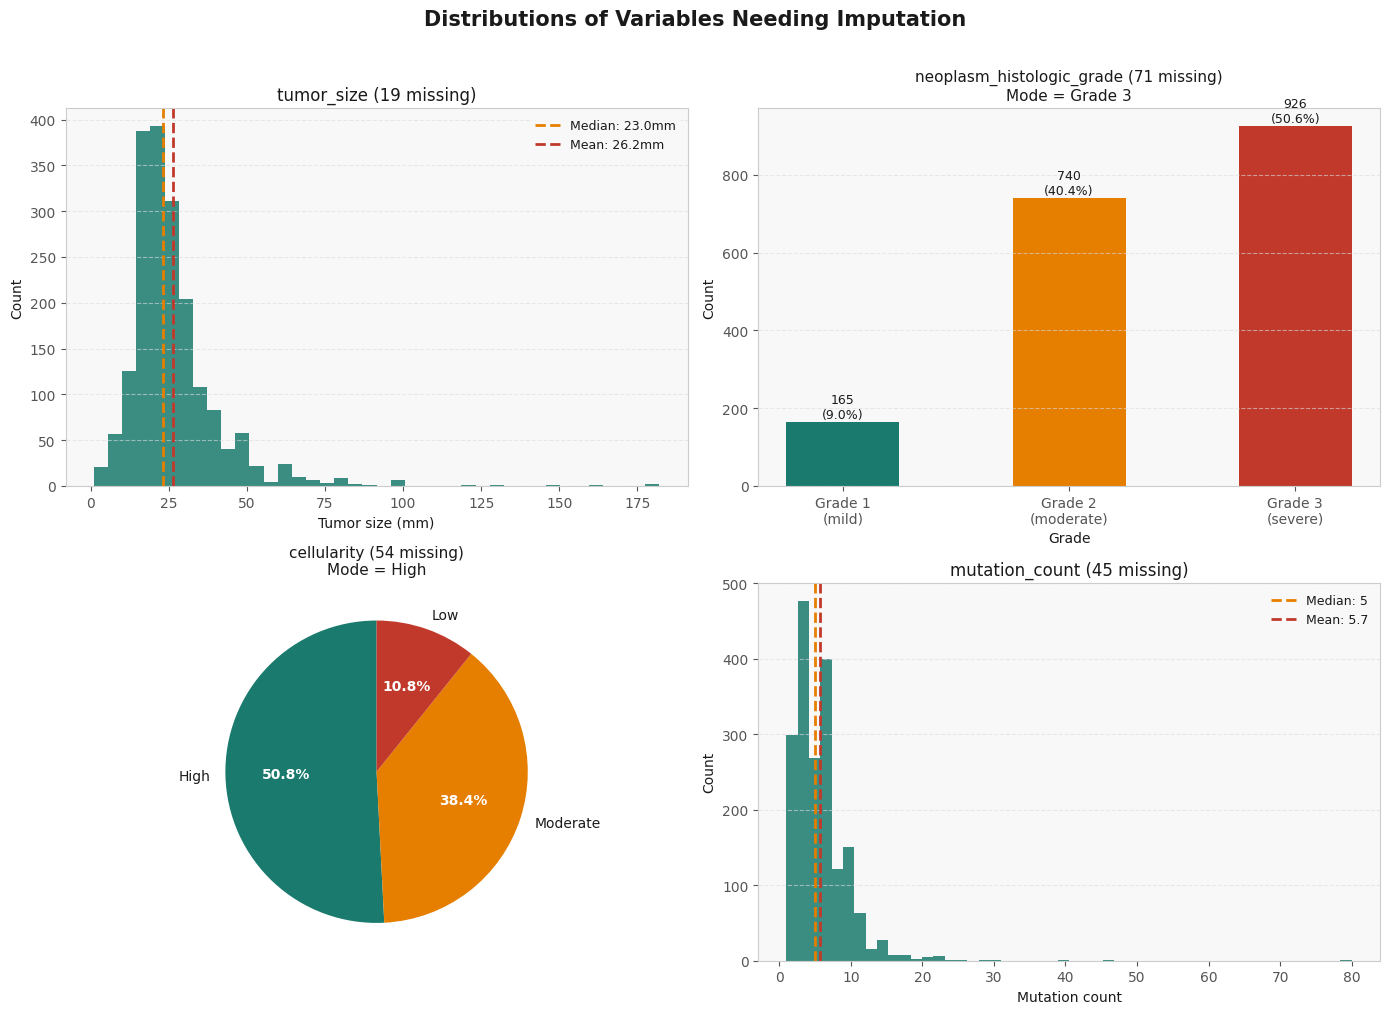

In [16]:
# distributions of variables needing imputation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('Distributions of Variables Needing Imputation', 
             fontsize=15, fontweight='bold', color=COLOR_TEXT, y=1.01)

ax = axes[0, 0]
ax.hist(df['tumor_size'].dropna(), bins=40, color=COLOR_PRESENT, 
        edgecolor='none', alpha=0.85)
ax.axvline(df['tumor_size'].median(), color=COLOR_ACCENT, 
           linewidth=2, linestyle='--', label=f"Median: {df['tumor_size'].median():.1f}mm")
ax.axvline(df['tumor_size'].mean(), color=COLOR_MISSING,  
           linewidth=2, linestyle='--', label=f"Mean: {df['tumor_size'].mean():.1f}mm")
ax.set_title('tumor_size (19 missing)', fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('Tumor size (mm)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

ax = axes[0, 1]
grade_counts = df['neoplasm_histologic_grade'].value_counts().sort_index()
bars = ax.bar(grade_counts.index.astype(str), grade_counts.values,
              color=[COLOR_PRESENT, COLOR_ACCENT, COLOR_MISSING],
              edgecolor='none', width=0.5)
for bar, val in zip(bars, grade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val}\n({100*val/grade_counts.sum():.1f}%)',
            ha='center', fontsize=9, color=COLOR_TEXT)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Grade 1\n(mild)', 'Grade 2\n(moderate)', 'Grade 3\n(severe)'])
ax.set_xlabel('Grade', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
mode_grade = df['neoplasm_histologic_grade'].mode()[0]
ax.set_title(f'neoplasm_histologic_grade (71 missing)\nMode = Grade {int(mode_grade)}', 
             fontsize=11, color=COLOR_TEXT)
ax.grid(axis='y')

ax = axes[1, 0]
cell_counts = df['cellularity'].value_counts()
colors_cell = [COLOR_PRESENT, COLOR_ACCENT, COLOR_MISSING]
wedges, texts, autotexts = ax.pie(
    cell_counts.values, 
    labels=cell_counts.index,
    autopct='%1.1f%%',
    colors=colors_cell[:len(cell_counts)],
    startangle=90,
    textprops={'color': COLOR_TEXT, 'fontsize': 10}
)
for at in autotexts:
    at.set_color(COLOR_BG)
    at.set_fontweight('bold')
ax.set_title(f'cellularity (54 missing)\nMode = {df["cellularity"].mode()[0]}', 
             fontsize=11, color=COLOR_TEXT)

ax = axes[1, 1]
mc = df['mutation_count'].dropna()
ax.hist(mc, bins=50, color=COLOR_PRESENT, edgecolor='none', alpha=0.85)
ax.axvline(mc.median(), color=COLOR_ACCENT, linewidth=2, linestyle='--',
           label=f"Median: {mc.median():.0f}")
ax.axvline(mc.mean(), color=COLOR_MISSING, linewidth=2, linestyle='--',
           label=f"Mean: {mc.mean():.1f}")
ax.set_title(f'mutation_count (45 missing)', fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('Mutation count', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

plt.tight_layout()
plt.show()

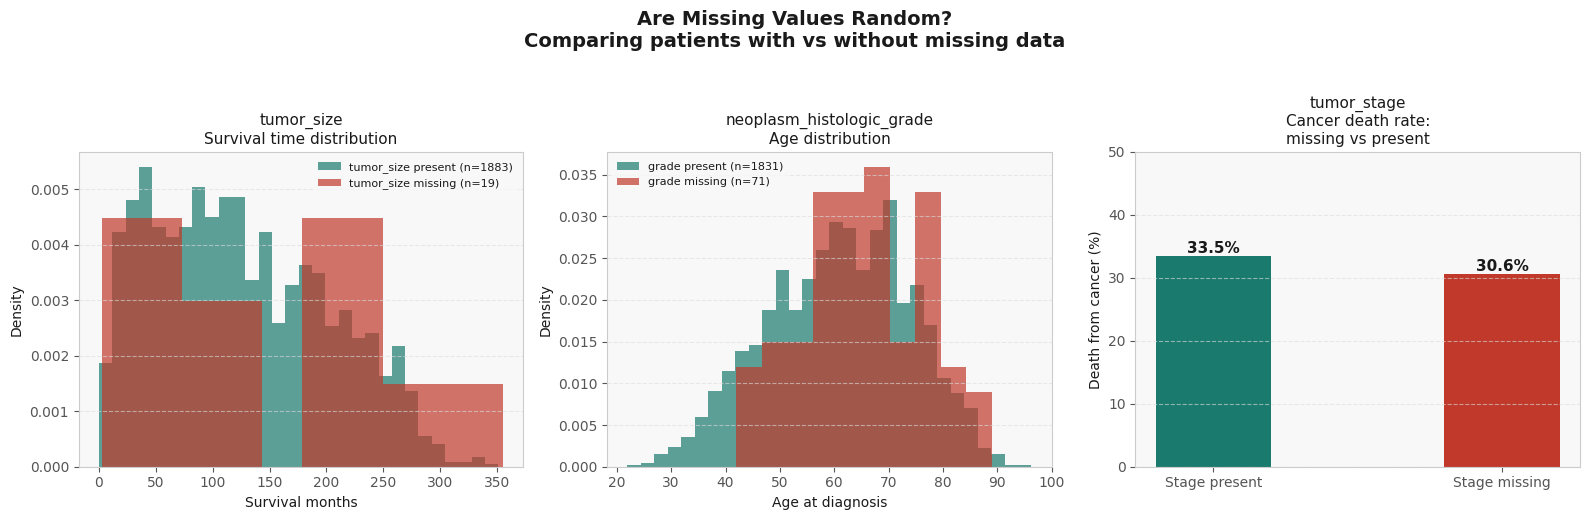

In [17]:
# are missing values random?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('Are Missing Values Random?\nComparing patients with vs without missing data', 
             fontsize=14, fontweight='bold', color=COLOR_TEXT, y=1.03)

ax = axes[0]
present = df[df['tumor_size'].notna()]['overall_survival_months']
missing = df[df['tumor_size'].isna()]['overall_survival_months']
ax.hist(present, bins=30, alpha=0.7, color=COLOR_PRESENT, 
        label=f'tumor_size present (n={len(present)})', density=True)
ax.hist(missing, bins=10, alpha=0.7, color=COLOR_MISSING,  
        label=f'tumor_size missing (n={len(missing)})', density=True)
ax.set_title('tumor_size\nSurvival time distribution', fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Survival months', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=8, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

ax = axes[1]
present_age = df[df['neoplasm_histologic_grade'].notna()]['age_at_diagnosis']
missing_age = df[df['neoplasm_histologic_grade'].isna()]['age_at_diagnosis']
ax.hist(present_age, bins=30, alpha=0.7, color=COLOR_PRESENT,
        label=f'grade present (n={len(present_age)})', density=True)
ax.hist(missing_age, bins=10, alpha=0.7, color=COLOR_MISSING,
        label=f'grade missing (n={len(missing_age)})', density=True)
ax.set_title('neoplasm_histologic_grade\nAge distribution', fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Age at diagnosis', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=8, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

ax = axes[2]
stage_present_event = df[df['tumor_stage'].notna()]['event'].mean()
stage_missing_event = df[df['tumor_stage'].isna()]['event'].mean()
bars = ax.bar(['Stage present', 'Stage missing'],
              [stage_present_event * 100, stage_missing_event * 100],
              color=[COLOR_PRESENT, COLOR_MISSING],
              edgecolor='none', width=0.4)
for bar, val in zip(bars, [stage_present_event, stage_missing_event]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', fontsize=11, 
            fontweight='bold', color=COLOR_TEXT)
ax.set_title('tumor_stage\nCancer death rate:\nmissing vs present', 
             fontsize=11, color=COLOR_TEXT)
ax.set_ylabel('Death from cancer (%)', fontsize=10)
ax.set_ylim(0, 50)
ax.grid(axis='y')

plt.tight_layout()
plt.show()

## Key findings

To assess whether missing values could be considered ignorable, patients were divided into two groups: those with the variable recorded and those without, and their distributions were compared across clinically relevant outcomes and demographic characteristics.

For **`tumor_size`**, patients with missing values exhibited a survival time distribution shifted toward longer survival durations (approximately 150–350 months), suggesting that the missing subgroup may differ systematically from the overall cohort. This indicates that simple median imputation could distort the underlying survival distribution.

For **`neoplasm_histologic_grade`**, patients with missing values were systematically older (with a peak age distribution around 65–80 years compared to 50–60 years for patients with recorded grades). This pattern is consistent with less complete pathology documentation in older cohort participants and suggests that mode imputation with Grade 3 — the most frequent and clinically most aggressive category — would incorrectly characterize this subgroup and potentially introduce systematic bias.

For **`tumor_stage`**, the cancer death rate was similar between patients with recorded stage information (33.5%) and those with missing values (30.6%), suggesting no strong evidence of outcome-related bias associated with missingness in this variable.

These findings motivated the use of **MICE (Multiple Imputation by Chained Equations)** for variables such as `tumor_size` and `neoplasm_histologic_grade`, where simple median or mode imputation could introduce systematic bias. In contrast, `tumor_stage` was excluded from downstream modeling due to its substantial missingness burden (26%) and its overlapping prognostic information with variables already retained in the dataset, including `tumor_size`, `lymph_nodes_examined_positive`, and `neoplasm_histologic_grade`.

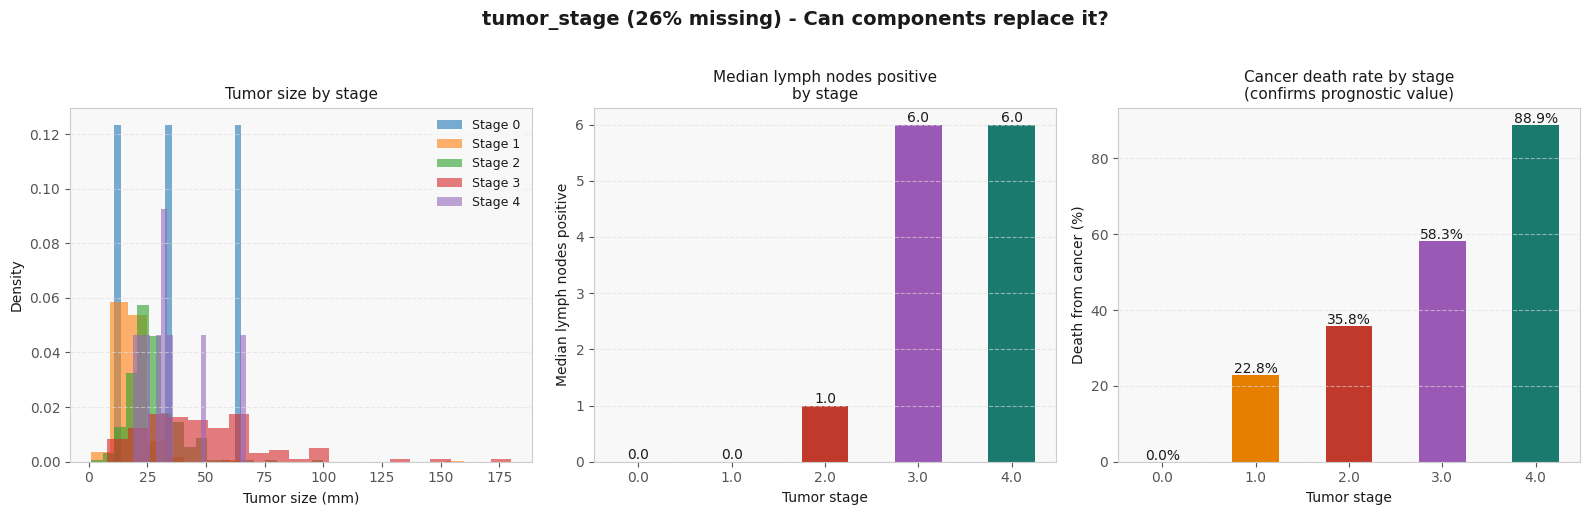

In [18]:
# tumor_stage: can components replace it?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('tumor_stage (26% missing) - Can components replace it?', 
             fontsize=14, fontweight='bold', color=COLOR_TEXT, y=1.02)

ax = axes[0]
for stage in sorted(df['tumor_stage'].dropna().unique()):
    data = df[df['tumor_stage'] == stage]['tumor_size'].dropna()
    ax.hist(data, bins=20, alpha=0.6, label=f'Stage {int(stage)}', density=True)
ax.set_title('Tumor size by stage', fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Tumor size (mm)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

ax = axes[1]
stage_lymph = df.groupby('tumor_stage')['lymph_nodes_examined_positive'].median()
bars = ax.bar(stage_lymph.index.astype(str), stage_lymph.values,
              color=[COLOR_PRESENT, COLOR_ACCENT, COLOR_MISSING, '#9B59B6'],
              edgecolor='none', width=0.5)
for bar, val in zip(bars, stage_lymph.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', fontsize=10, color=COLOR_TEXT)
ax.set_title('Median lymph nodes positive\nby stage', fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Tumor stage', fontsize=10)
ax.set_ylabel('Median lymph nodes positive', fontsize=10)
ax.grid(axis='y')

ax = axes[2]
stage_event = df.groupby('tumor_stage')['event'].mean() * 100
bars = ax.bar(stage_event.index.astype(str), stage_event.values,
              color=[COLOR_PRESENT, COLOR_ACCENT, COLOR_MISSING, '#9B59B6'],
              edgecolor='none', width=0.5)
for bar, val in zip(bars, stage_event.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, color=COLOR_TEXT)
ax.set_title('Cancer death rate by stage\n(confirms prognostic value)', 
             fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Tumor stage', fontsize=10)
ax.set_ylabel('Death from cancer (%)', fontsize=10)
ax.grid(axis='y')

plt.tight_layout()
plt.show()

## Key findings

Since `tumor_stage` is missing for 26.3% of patients, additional analyses were performed to evaluate whether its prognostic information substantially overlaps with variables already retained in the dataset, including `tumor_size`, `lymph_nodes_examined_positive`, and `neoplasm_histologic_grade`.

Tumor size distributions shift consistently across stages, lymph node involvement increases markedly from stages 0–1 to stages 3–4, and cancer death rates rise progressively from 0% at stage 0 to 88.9% at stage 4. These trends indicate that `tumor_stage` functions as an aggregate clinical descriptor strongly associated with tumor burden and nodal involvement, both of which are already represented by retained component variables.

Given the substantial missingness burden (26.3%) and the strong overlap in prognostic structure with existing variables, `tumor_stage` was excluded from downstream modeling in favor of its component clinical predictors. This approach retains clinically relevant prognostic information while avoiding the uncertainty and potential bias introduced by imputing a highly incomplete variable.

# Imputation - My Final Verdict

### Drop
- **`tumor_stage`**: 26.3% missing, components fully replace it, death rate identical for missing vs present patients (33.5% vs 30.6%)

### Rule-based reconstruction
- **`3-gene_classifier_subtype`**: derived deterministically from `er_status`, `pr_status`, `her2_status`, all of which are 100% complete

### MICE (Multiple Imputation by Chained Equations)
- **`tumor_size`**: right-skewed distribution, missing patients are systematically longer survivors; median would bias toward average-sized tumors for patients who likely had smaller ones
- **`neoplasm_histologic_grade`**: missing patients are systematically older (peak 65–80 vs 50–60); mode (Grade 3) would incorrectly label older patients as most aggressive
- **`cellularity`**: mode (High, 50.8%) would bias all missing patients toward the most aggressive category
- **`mutation_count`**: right-skewed with a long tail; multivariate context improves imputation over simple median

### Mode
- **`primary_tumor_laterality`**: weak prognostic value, missingness appears random
- **`type_of_breast_surgery`**: low missing rate (1.1%), treatment decision not well predicted by tumor biology
- **`cancer_type_detailed`**: high cardinality categorical, low missing rate (0.79%)

In [19]:
df_before_stage_drop = df.copy()

In [20]:
df = df.drop(columns=['tumor_stage'])
print(f"tumor_stage dropped. Remaining columns: {df.shape[1]}")

tumor_stage dropped. Remaining columns: 687


In [15]:
pd.crosstab(
    [df['er_status'], df['pr_status'], df['her2_status']],
    df['3-gene_classifier_subtype']
)

3-gene_classifier_subtype        ER+/HER2- High Prolif  ER+/HER2- Low Prolif  \
er_status pr_status her2_status                                                
Negative  Negative  Negative                         7                     8   
                    Positive                         1                     2   
          Positive  Negative                         1                     1   
                    Positive                         0                     0   
Positive  Negative  Negative                       203                   140   
                    Positive                        11                     3   
          Positive  Negative                       368                   463   
                    Positive                        11                     2   

3-gene_classifier_subtype        ER-/HER2-  HER2+  
er_status pr_status her2_status                    
Negative  Negative  Negative           228      4  
                    Positive            12    103  
          Positive  Negative             8      1  
                    Positive             1      4  
Positive  Negative  Negative            27      7  
                    Positive             1     39  
          Positive  Negative            12      2  
                    Positive             0     28

In [16]:
print('tumor_stage' in df.columns)

False


In [21]:
clinical_cols = [c for c in clinical_cols if c != 'tumor_stage']

In [22]:
# mode imputation for low-signal categoricals
mode_cols = [
    'primary_tumor_laterality',
    'type_of_breast_surgery',
    'cancer_type_detailed'
]

for col in mode_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"{col}: mode = '{mode_val}'")

primary_tumor_laterality: mode = 'Left'
type_of_breast_surgery: mode = 'MASTECTOMY'
cancer_type_detailed: mode = 'Breast Invasive Ductal Carcinoma'


In [23]:
# conservative handling for biologically meaningful categorical subtype
df['3-gene_classifier_subtype'] = df['3-gene_classifier_subtype'].fillna('Unknown')

# MICE for important variables
mice_predictors = [
    'age_at_diagnosis',
    'tumor_size',
    'lymph_nodes_examined_positive',
    'nottingham_prognostic_index',
    'mutation_count',
    'neoplasm_histologic_grade',
    'cellularity',
    'er_status',
    'pr_status',
    'her2_status'
]

mice_targets = [
    'tumor_size',
    'mutation_count',
    'neoplasm_histologic_grade',
    'cellularity'
]

encode_map = {
    'er_status': {'Positive': 1, 'Negative': 0},
    'pr_status': {'Positive': 1, 'Negative': 0},
    'her2_status': {'Positive': 1, 'Negative': 0},
    'cellularity': {'Low': 1, 'Moderate': 2, 'High': 3},
    'neoplasm_histologic_grade': {1: 1, 2: 2, 3: 3}
}

decode_map = {
    'cellularity': {1: 'Low', 2: 'Moderate', 3: 'High'}
}

# Record missing rows before imputation
missing_masks = {
    col: df[col].isnull().copy()
    for col in mice_targets
}

# Prepare imputation dataframe
mice_df = df[mice_predictors].copy()

for col, mapping in encode_map.items():
    if col in mice_df.columns:
        mice_df[col] = mice_df[col].map(mapping)

# Safety check
if mice_df.isnull().sum().sum() == 0:
    print("No missing values found for MICE targets.")
else:
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=ConvergenceWarning)

        imputer = IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=50,
                random_state=42,
                n_jobs=-1
            ),
            max_iter=30,
            random_state=42,
            verbose=0
        )

        mice_imputed = imputer.fit_transform(mice_df)

    mice_df_imputed = pd.DataFrame(
        mice_imputed,
        columns=mice_predictors,
        index=df.index
    )

    # Convert imputed variables back to valid formats
    mice_df_imputed['neoplasm_histologic_grade'] = (
        mice_df_imputed['neoplasm_histologic_grade']
        .round()
        .clip(1, 3)
        .astype(int)
    )

    mice_df_imputed['cellularity'] = (
        mice_df_imputed['cellularity']
        .round()
        .clip(1, 3)
        .astype(int)
        .map(decode_map['cellularity'])
    )

    # Optional: mutation_count should be non-negative integer
    mice_df_imputed['mutation_count'] = (
        mice_df_imputed['mutation_count']
        .round()
        .clip(lower=0)
        .astype(int)
    )

    # Optional: tumor size should be positive
    mice_df_imputed['tumor_size'] = (
        mice_df_imputed['tumor_size']
        .clip(lower=0)
    )

    # Write back only originally missing values
    for col in mice_targets:
        n_missing = missing_masks[col].sum()
        df.loc[missing_masks[col], col] = mice_df_imputed.loc[missing_masks[col], col]
        print(f"{col}: {n_missing} values imputed via MICE")

print("\nRemaining missing values in clinical columns:")
remaining = df[clinical_cols].isnull().sum()
remaining_nonzero = remaining[remaining > 0]

if len(remaining_nonzero) == 0:
    print("All clinical columns complete. Ready to proceed.")
else:
    print(remaining_nonzero)

tumor_size: 19 values imputed via MICE
mutation_count: 45 values imputed via MICE
neoplasm_histologic_grade: 71 values imputed via MICE
cellularity: 54 values imputed via MICE

Remaining missing values in clinical columns:
All clinical columns complete. Ready to proceed.


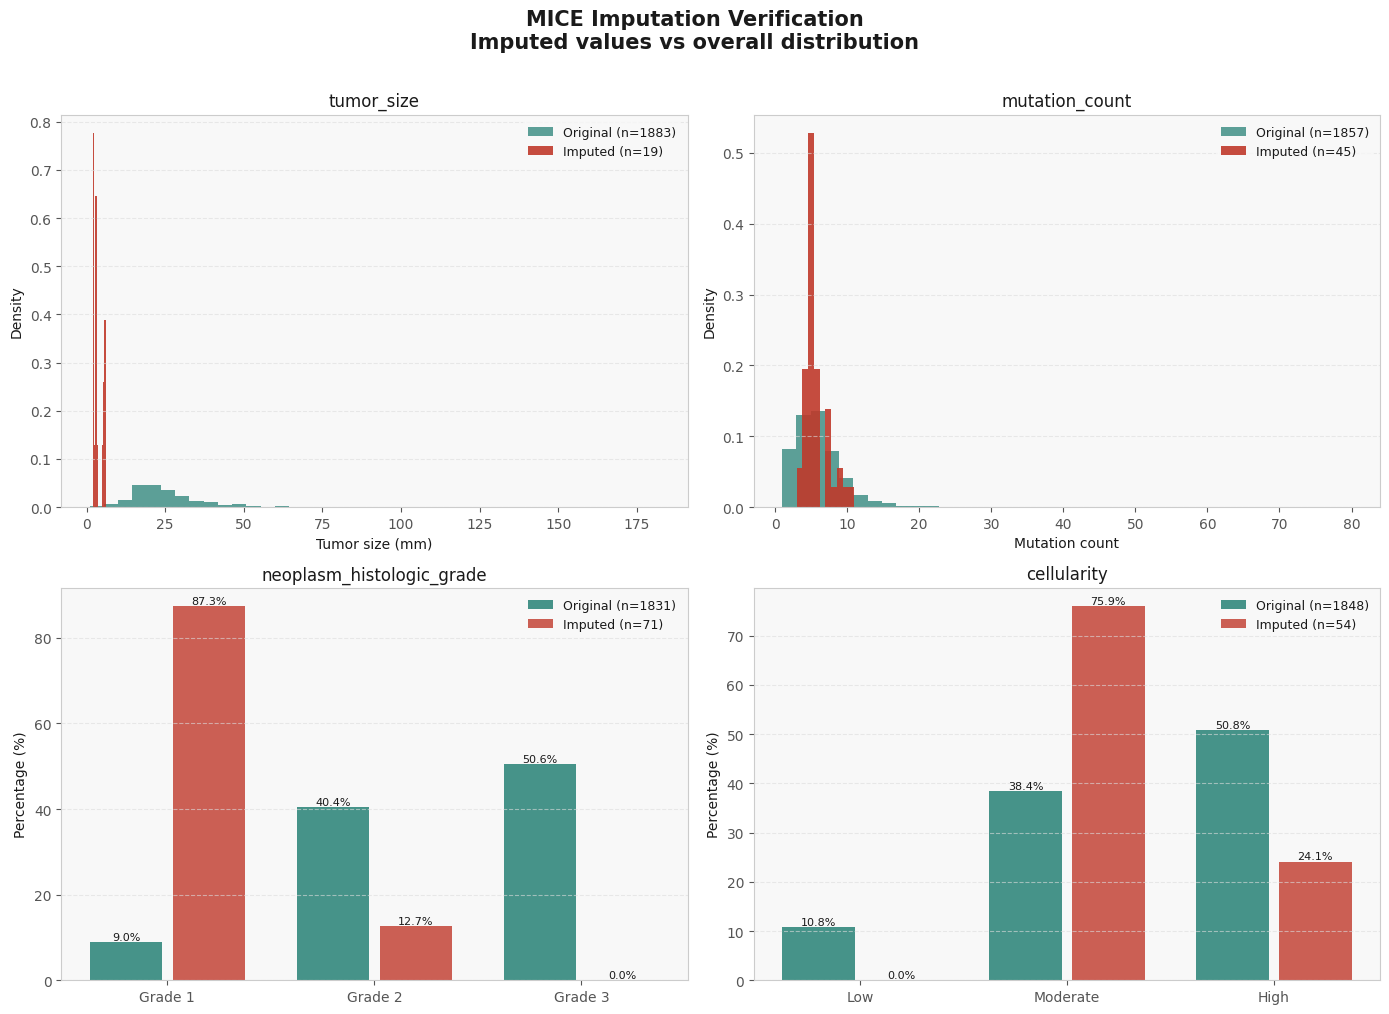

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('MICE Imputation Verification\nImputed values vs overall distribution', 
             fontsize=15, fontweight='bold', color=COLOR_TEXT, y=1.01)

# tumor_size
ax = axes[0, 0]
original_mask = ~missing_masks['tumor_size']
imputed_mask  =  missing_masks['tumor_size']

ax.hist(df.loc[original_mask, 'tumor_size'], bins=40, 
        color=COLOR_PRESENT, alpha=0.7, density=True,
        label=f'Original (n={original_mask.sum()})')
ax.hist(df.loc[imputed_mask, 'tumor_size'], bins=10,
        color=COLOR_MISSING, alpha=0.9, density=True,
        label=f'Imputed (n={imputed_mask.sum()})')
ax.set_title('tumor_size', fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('Tumor size (mm)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

# mutation_count
ax = axes[0, 1]
original_mask = ~missing_masks['mutation_count']
imputed_mask  =  missing_masks['mutation_count']

ax.hist(df.loc[original_mask, 'mutation_count'], bins=40,
        color=COLOR_PRESENT, alpha=0.7, density=True,
        label=f'Original (n={original_mask.sum()})')
ax.hist(df.loc[imputed_mask, 'mutation_count'], bins=10,
        color=COLOR_MISSING, alpha=0.9, density=True,
        label=f'Imputed (n={imputed_mask.sum()})')
ax.set_title('mutation_count', fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('Mutation count', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

# neoplasm_histologic_grade
ax = axes[1, 0]
original_mask = ~missing_masks['neoplasm_histologic_grade']
imputed_mask  =  missing_masks['neoplasm_histologic_grade']

grades = [1, 2, 3]
orig_counts = [df.loc[original_mask, 'neoplasm_histologic_grade'].eq(g).sum() 
               for g in grades]
imp_counts  = [df.loc[imputed_mask,  'neoplasm_histologic_grade'].eq(g).sum() 
               for g in grades]

orig_pct = [c / sum(orig_counts) * 100 for c in orig_counts]
imp_pct  = [c / sum(imp_counts)  * 100 for c in imp_counts]

x = np.arange(3)
bars1 = ax.bar(x - 0.2, orig_pct, width=0.35, color=COLOR_PRESENT, 
               alpha=0.8, label=f'Original (n={original_mask.sum()})')
bars2 = ax.bar(x + 0.2, imp_pct,  width=0.35, color=COLOR_MISSING,  
               alpha=0.8, label=f'Imputed (n={imputed_mask.sum()})')
for bar, val in zip(bars1, orig_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=8, color=COLOR_TEXT)
for bar, val in zip(bars2, imp_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=8, color=COLOR_TEXT)
ax.set_xticks(x)
ax.set_xticklabels(['Grade 1', 'Grade 2', 'Grade 3'])
ax.set_title('neoplasm_histologic_grade', fontsize=12, color=COLOR_TEXT)
ax.set_ylabel('Percentage (%)', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

# cellularity
ax = axes[1, 1]
original_mask = ~missing_masks['cellularity']
imputed_mask  =  missing_masks['cellularity']

cats = ['Low', 'Moderate', 'High']
orig_counts = [df.loc[original_mask, 'cellularity'].eq(c).sum() for c in cats]
imp_counts  = [df.loc[imputed_mask,  'cellularity'].eq(c).sum() for c in cats]

orig_pct = [c / sum(orig_counts) * 100 for c in orig_counts]
imp_pct  = [c / sum(imp_counts)  * 100 for c in imp_counts]

x = np.arange(3)
bars1 = ax.bar(x - 0.2, orig_pct, width=0.35, color=COLOR_PRESENT,
               alpha=0.8, label=f'Original (n={original_mask.sum()})')
bars2 = ax.bar(x + 0.2, imp_pct,  width=0.35, color=COLOR_MISSING,
               alpha=0.8, label=f'Imputed (n={imputed_mask.sum()})')
for bar, val in zip(bars1, orig_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=8, color=COLOR_TEXT)
for bar, val in zip(bars2, imp_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=8, color=COLOR_TEXT)
ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_title('cellularity', fontsize=12, color=COLOR_TEXT)
ax.set_ylabel('Percentage (%)', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

plt.tight_layout()
plt.show()

In [25]:
grade_mode = 3  # from my earlier analysis
cell_mode = 'High'

df.loc[missing_masks['neoplasm_histologic_grade'], 'neoplasm_histologic_grade'] = grade_mode
df.loc[missing_masks['cellularity'], 'cellularity'] = cell_mode

print(f"neoplasm_histologic_grade: {missing_masks['neoplasm_histologic_grade'].sum()} values reset to mode = {grade_mode}")
print(f"cellularity: {missing_masks['cellularity'].sum()} values reset to mode = '{cell_mode}'")

# Verify
print("\nGrade distribution after fix:")
print(df['neoplasm_histologic_grade'].value_counts().sort_index())
print("\nCellularity distribution after fix:")
print(df['cellularity'].value_counts())

neoplasm_histologic_grade: 71 values reset to mode = 3
cellularity: 54 values reset to mode = 'High'

Grade distribution after fix:
neoplasm_histologic_grade
1.0    165
2.0    740
3.0    997
Name: count, dtype: int64

Cellularity distribution after fix:
cellularity
High        993
Moderate    710
Low         199
Name: count, dtype: int64


# Key findings

Initial plans called for MICE imputation on `neoplasm_histologic_grade` and `cellularity`, motivated by earlier missingness analysis indicating that missing patients differed systematically from the observed cohort.

Post-imputation verification showed that MICE generated highly concentrated imputations for these ordinal variables, substantially altering their original category distributions. Given the relatively small number of missing observations (n=71 and n=54), these results likely reflect instability and overconfidence of iterative Random Forest imputation on low-cardinality ordinal variables.

Because both MICE and pure mode imputation introduced strong assumptions, these variables were ultimately treated conservatively in downstream analyses.

## Mutation columns

In [26]:
mutation_cols = [c for c in df.columns if c.endswith('_mut')]
print(f"Total mutation columns: {len(mutation_cols)}")

# check what values they currently contain
print("\nSample of unique values across mutation columns:")
for col in mutation_cols[:5]:
    print(f"{col}: {df[col].unique()}")

Total mutation columns: 173

Sample of unique values across mutation columns:
pik3ca_mut: ['0' 'H1047R' 'E542K' 'Q546H G1049R' 'E545K' 'N345K E81K' 'H1047L E726K'
 'H1047L' 'E545Q' 'N345K' 'L452Kfs*4 E453Dfs*7' 'N345K N1044K'
 'E365K C420R' 'E545K H1047R' 'E542K E726K' 'E453_L455del' 'G451_D454del'
 'E110del' 'Q546K' 'H1047R E453K' 'R88Q' 'H1047R P104L' 'H1047R E726K'
 'M1043V' 'Q546P' 'N1068Kfs*5' 'H1047R R108H' 'K111E' 'H1047R G118D'
 'H1047R H1048R' 'E545G' 'E542K N345K' 'E545K G320A' 'E545K S509Y' 'E418K'
 'E545K G914R' 'H1047R L10_P17del' 'C420R' 'P449S' 'E545K E726K'
 'H1047R E81K' 'Q546R' 'H1047R D1029H H1048R' 'E545K M1043V' 'P449T'
 'V105del K148N' 'A1066Cfs*7' 'H1047R T727K' 'E545A' 'H1047R E80K' 'E726K'
 'H1047L E385K' 'H1047R K111E' 'E542K T727K' 'M1043I' 'H1047R P471L'
 'E726K P449_L452del' 'G118D' 'N345K M1043I' 'Y1021Hfs*9' 'P447_L455del'
 'Q546H' 'Q546R E453K' 'E542K Y1021H' 'R108del' 'M1043V E726K'
 'E545K D725N' 'H1047R E365K' '*1069Lfs*5' 'E453_G460delinsD' 'H1047Y'


In [27]:
# how many are already numeric vs string
object_mut_cols = [c for c in mutation_cols if df[c].dtype == object]
numeric_mut_cols = [c for c in mutation_cols if df[c].dtype != object]
print(f"String mutation columns: {len(object_mut_cols)}")
print(f"Already numeric: {len(numeric_mut_cols)}")

String mutation columns: 173
Already numeric: 0


In [28]:
# converting all mutation columns to binary
# '0' = no mutation → 0, anything else = mutated → 1
for col in mutation_cols:
    df[col] = df[col].apply(lambda x: 0 if str(x).strip() == '0' else 1)

# verifying conversion worked
print("After conversion - sample unique values:")
for col in mutation_cols[:5]:
    print(f"{col}: {df[col].unique()}")

print(f"\nDtype after conversion:")
print(df[mutation_cols].dtypes.value_counts())

# mutation frequency: what fraction of patients carry each mutation?
mut_freq = df[mutation_cols].mean().sort_values(ascending=False)
print(f"\nTop 10 most common mutations:")
print(mut_freq.head(10))

print(f"\nMutations in fewer than 1% of patients:")
rare = mut_freq[mut_freq < 0.01]
print(f"Count: {len(rare)}")

After conversion - sample unique values:
pik3ca_mut: [0 1]
tp53_mut: [0 1]
muc16_mut: [0 1]
ahnak2_mut: [0 1]
kmt2c_mut: [0 1]

Dtype after conversion:
int64    173
Name: count, dtype: int64

Top 10 most common mutations:
pik3ca_mut    0.417455
tp53_mut      0.345426
muc16_mut     0.171399
ahnak2_mut    0.163512
kmt2c_mut     0.123028
syne1_mut     0.121977
gata3_mut     0.120925
map3k1_mut    0.104101
dnah11_mut    0.092008
ahnak_mut     0.091483
dtype: float64

Mutations in fewer than 1% of patients:
Count: 58


# Key findings about mutations

Upon inspection, all 173 mutation columns were stored as strings rather than binary integers: containing the specific amino acid change notation for each mutation (e.g. `H1047R`, `S241F`) and `'0'` to indicate no mutation. While this encoding carries biological meaning in targeted therapy contexts, I think that it is not suitable for survival modeling: most individual mutation variants appear in only a handful of patients, making them statistically unlearnable, and standard practice in survival analysis with genomic data is to encode mutation status as binary (mutated/not mutated).

Therefore, all 173 columns were converted to binary( `'0'` mapped to 0 (no mutation) and any other value mapped to 1 (mutation present)) — resulting in clean int64 columns. Of the 173 columns, 58 have a mutation frequency below 1% (fewer than 19 patients).

## Gene expression Columns

In [29]:
# identifying gene expression columns
non_expression_cols = (clinical_cols + mutation_cols + 
                       ['patient_id', 'overall_survival', 
                        'death_from_cancer', 'event',
                        'overall_survival_months'])

expression_cols = [c for c in df.columns if c not in non_expression_cols]
print(f"Gene expression columns: {len(expression_cols)}")

Gene expression columns: 489


In [30]:
# basic sanity check on z-score ranges
expr_stats = df[expression_cols].describe().T

print(f"\nZ-score range across all genes:")
print(f"Global min:    {expr_stats['min'].min():.3f}")
print(f"Global max:    {expr_stats['max'].max():.3f}")
print(f"Mean of means: {expr_stats['mean'].mean():.3f}")
print(f"Mean of stds:  {expr_stats['std'].mean():.3f}")


Z-score range across all genes:
Global min:    -7.243
Global max:    20.395
Mean of means: -0.000
Mean of stds:  1.000


In [78]:
# check for near-zero variance columns
low_var = expr_stats[expr_stats['std'] < 0.1]
print(f"\nLow variance columns (std < 0.1): {len(low_var)}")


Low variance columns (std < 0.1): 0


In [31]:
# check for missing values
expr_missing = df[expression_cols].isnull().sum()
expr_missing_nonzero = expr_missing[expr_missing > 0]
print(f"\nExpression columns with missing values: {len(expr_missing_nonzero)}")
if len(expr_missing_nonzero) > 0:
    print(expr_missing_nonzero)


Expression columns with missing values: 0


In [32]:
# find what's in expression_cols that shouldn't be
print("Non-numeric columns in expression_cols (should be empty):")
non_numeric = [c for c in expression_cols if df[c].dtype == object]
print(non_numeric)

print(f"\nFloat/int columns that look clinical:")
suspicious = [c for c in expression_cols if df[c].dtype != float]
print(suspicious)

print(f"\nFirst 20 expression column names:")
print(expression_cols[:20])

print(f"\nLast 20 expression column names:")
print(expression_cols[-20:])

Non-numeric columns in expression_cols (should be empty):
[]

Float/int columns that look clinical:
[]

First 20 expression column names:
['brca1', 'brca2', 'palb2', 'pten', 'tp53', 'atm', 'cdh1', 'chek2', 'nbn', 'nf1', 'stk11', 'bard1', 'mlh1', 'msh2', 'msh6', 'pms2', 'epcam', 'rad51c', 'rad51d', 'rad50']

Last 20 expression column names:
['prkci', 'prkd1', 'ran', 'rdh5', 'sdc4', 'serpini1', 'shbg', 'slc29a1', 'sox9', 'spry2', 'srd5a1', 'srd5a2', 'srd5a3', 'st7', 'star', 'tnk2', 'tulp4', 'ugt2b15', 'ugt2b17', 'ugt2b7']


In [30]:
print(f"Expression columns: {len(expression_cols)}")
print(f"Mutation columns:   {len(mutation_cols)}")
print(f"Clinical columns:   {len(clinical_cols)}")
print(f"Other columns:      overall_survival, death_from_cancer, event, overall_survival_months")
print(f"Total in df:        {df.shape[1]}")
print(f"Sum check:          {len(expression_cols) + len(mutation_cols) + len(clinical_cols) + 4}")

Expression columns: 489
Mutation columns:   173
Clinical columns:   21
Other columns:      overall_survival, death_from_cancer, event, overall_survival_months
Total in df:        687
Sum check:          687


In [33]:
# check mutation columns for near-zero variance
mut_freq = df[mutation_cols].mean()
constant_mut = mut_freq[mut_freq < 0.01]
print(f"Mutation columns with < 1% frequency: {len(constant_mut)}")

# check clinical columns for single unique value
for col in clinical_cols:
    n_unique = df[col].nunique()
    if n_unique <= 1:
        print(f"Constant column: {col} — {n_unique} unique value")

Mutation columns with < 1% frequency: 58


## Layer 2 asks: what does survival look like in this dataset, before any modeling?

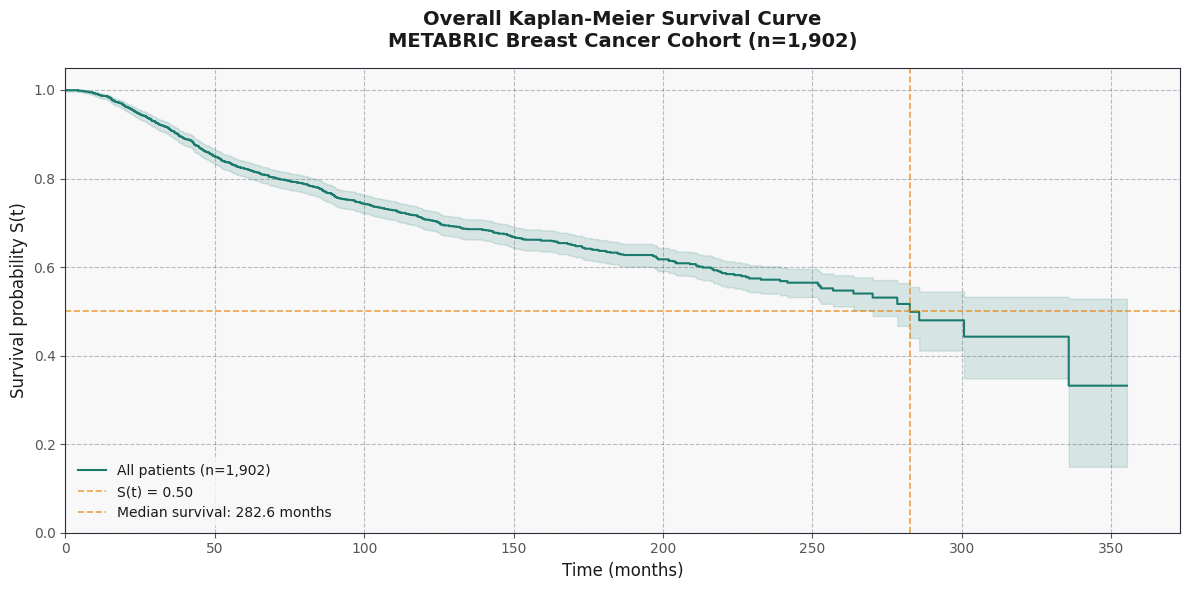

Median survival time: 282.6 months (23.5 years)
5-year survival:  0.822
10-year survival: 0.709
15-year survival: 0.636


In [34]:
# overall KM curve
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_CARD)

kmf = KaplanMeierFitter()
kmf.fit(
    durations=df['overall_survival_months'],
    event_observed=df['event'],
    label='All patients (n=1,902)'
)

kmf.plot_survival_function(
    ax=ax,
    ci_show=True,
    color=COLOR_PRESENT,
    ci_alpha=0.15
)

# median survival line
median_surv = kmf.median_survival_time_
ax.axhline(y=0.5, color=COLOR_ACCENT, linestyle='--', 
           alpha=0.7, linewidth=1.2, label=f'S(t) = 0.50')
ax.axvline(x=median_surv, color=COLOR_ACCENT, linestyle='--',
           alpha=0.7, linewidth=1.2, label=f'Median survival: {median_surv:.1f} months')

ax.set_title('Overall Kaplan-Meier Survival Curve\nMETABRIC Breast Cancer Cohort (n=1,902)', 
             fontsize=14, fontweight='bold', color=COLOR_TEXT, pad=15)
ax.set_xlabel('Time (months)', fontsize=12, color=COLOR_TEXT)
ax.set_ylabel('Survival probability S(t)', fontsize=12, color=COLOR_TEXT)
ax.tick_params(colors=COLOR_SUBTEXT)
ax.set_ylim(0, 1.05)
ax.set_xlim(0)
ax.grid(True, alpha=0.3, color='#2A2D3A')
ax.legend(fontsize=10, facecolor=COLOR_CARD, edgecolor='none', labelcolor=COLOR_TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

plt.tight_layout()

plt.show()
print(f"Median survival time: {median_surv:.1f} months ({median_surv/12:.1f} years)")
print(f"5-year survival:  {kmf.survival_function_at_times(60).values[0]:.3f}")
print(f"10-year survival: {kmf.survival_function_at_times(120).values[0]:.3f}")
print(f"15-year survival: {kmf.survival_function_at_times(180).values[0]:.3f}")

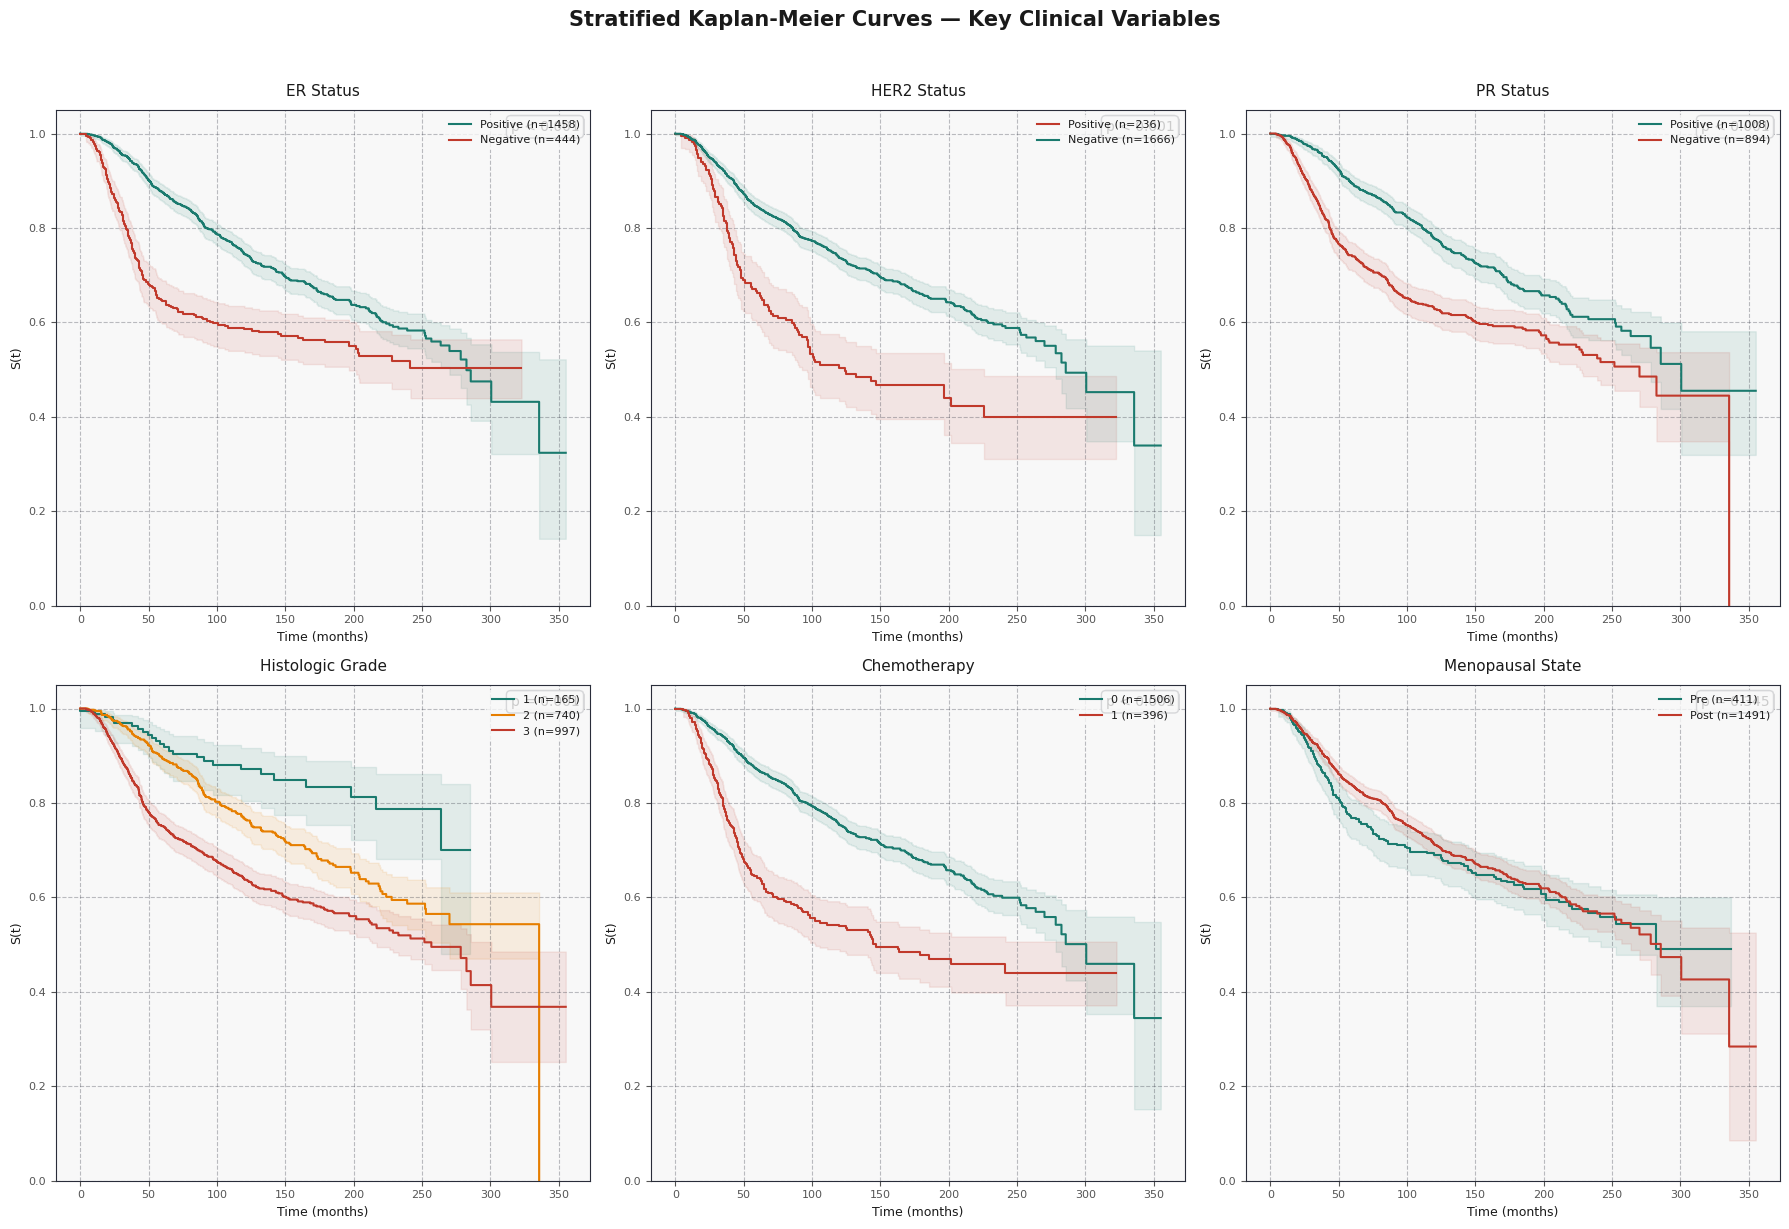

In [35]:
from lifelines.statistics import logrank_test

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('Stratified Kaplan-Meier Curves — Key Clinical Variables',
             fontsize=15, fontweight='bold', color=COLOR_TEXT, y=1.02)

def plot_stratified_km(ax, df, group_col, groups, colors, title):
    for group, color in zip(groups, colors):
        mask = df[group_col] == group
        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=df.loc[mask, 'overall_survival_months'],
            event_observed=df.loc[mask, 'event'],
            label=f'{group} (n={mask.sum()})'
        )
        kmf.plot_survival_function(ax=ax, ci_show=True, 
                                   color=color, ci_alpha=0.1)
    
    # log-rank test between first two groups
    g1 = groups[0]
    g2 = groups[1]
    mask1 = df[group_col] == g1
    mask2 = df[group_col] == g2
    results = logrank_test(
        df.loc[mask1, 'overall_survival_months'],
        df.loc[mask2, 'overall_survival_months'],
        event_observed_A=df.loc[mask1, 'event'],
        event_observed_B=df.loc[mask2, 'event']
    )
    p = results.p_value
    p_text = f'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.text(0.98, 0.98, p_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            color=COLOR_TEXT, 
            bbox=dict(boxstyle='round', facecolor=COLOR_CARD, 
                      edgecolor='#2A2D3A', alpha=0.8))
    
    ax.set_title(title, fontsize=11, color=COLOR_TEXT, pad=10)
    ax.set_xlabel('Time (months)', fontsize=9, color=COLOR_TEXT)
    ax.set_ylabel('S(t)', fontsize=9, color=COLOR_TEXT)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, color='#2A2D3A')
    ax.tick_params(colors=COLOR_SUBTEXT, labelsize=8)
    ax.legend(fontsize=8, facecolor=COLOR_CARD, 
              edgecolor='none', labelcolor=COLOR_TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2A2D3A')

# er_status
plot_stratified_km(
    axes[0,0], df, 'er_status',
    ['Positive', 'Negative'],
    [COLOR_PRESENT, COLOR_MISSING],
    'ER Status'
)

# her2_status
plot_stratified_km(
    axes[0,1], df, 'her2_status',
    ['Positive', 'Negative'],
    [COLOR_MISSING, COLOR_PRESENT],
    'HER2 Status'
)

# pr_status
plot_stratified_km(
    axes[0,2], df, 'pr_status',
    ['Positive', 'Negative'],
    [COLOR_PRESENT, COLOR_MISSING],
    'PR Status'
)

# neoplasm_histologic_grade
plot_stratified_km(
    axes[1,0], df, 'neoplasm_histologic_grade',
    [1, 2, 3],
    [COLOR_PRESENT, COLOR_ACCENT, COLOR_MISSING],
    'Histologic Grade'
)

# chemotherapy
plot_stratified_km(
    axes[1,1], df, 'chemotherapy',
    [0, 1],
    [COLOR_PRESENT, COLOR_MISSING],
    'Chemotherapy'
)

# inferred_menopausal_state
plot_stratified_km(
    axes[1,2], df, 'inferred_menopausal_state',
    ['Pre', 'Post'],
    [COLOR_PRESENT, COLOR_MISSING],
    'Menopausal State'
)

plt.tight_layout()
plt.show()

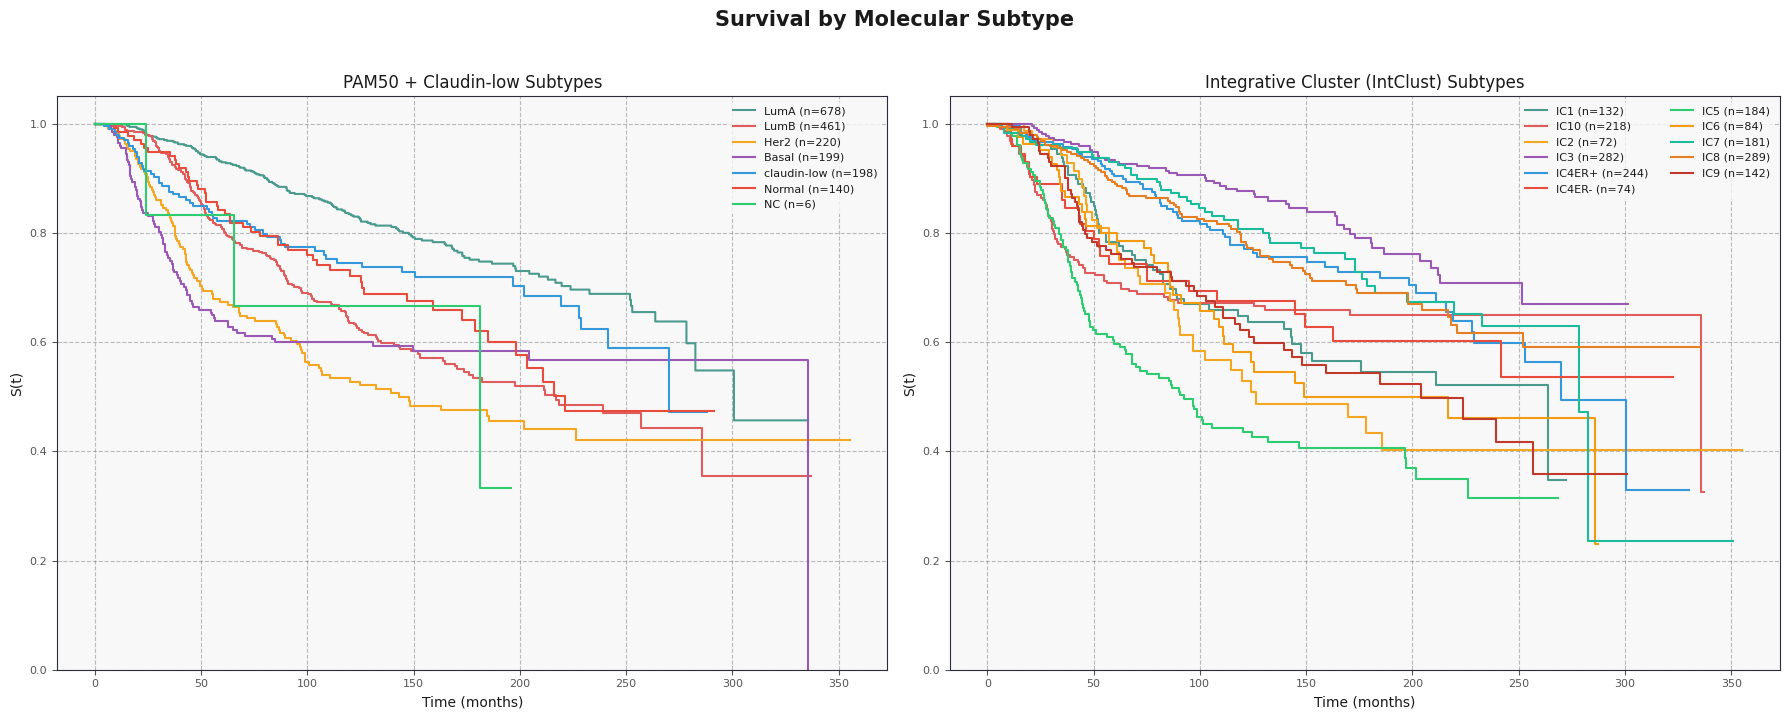

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('Survival by Molecular Subtype',
             fontsize=15, fontweight='bold', color=COLOR_TEXT, y=1.02)

# PAM50 subtypes
ax = axes[0]
pam50_colors = ['#4A9B8E', '#E05C5C', '#F5A623', '#9B59B6', '#3498DB', '#E74C3C', '#2ECC71']
pam50_groups = df['pam50_+_claudin-low_subtype'].value_counts().index.tolist()

for i, group in enumerate(pam50_groups):
    mask = df['pam50_+_claudin-low_subtype'] == group
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=df.loc[mask, 'overall_survival_months'],
        event_observed=df.loc[mask, 'event'],
        label=f'{group} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=pam50_colors[i % len(pam50_colors)])

ax.set_title('PAM50 + Claudin-low Subtypes', fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('Time (months)', fontsize=10)
ax.set_ylabel('S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, color='#2A2D3A')
ax.tick_params(colors=COLOR_SUBTEXT, labelsize=8)
ax.legend(fontsize=8, facecolor=COLOR_CARD, edgecolor='none', labelcolor=COLOR_TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

# IntClust subtypes
ax = axes[1]
intclust_colors = ['#4A9B8E', '#E05C5C', '#F5A623', '#9B59B6', '#3498DB',
                   '#E74C3C', '#2ECC71', '#F39C12', '#1ABC9C', '#E67E22', '#C0392B']
intclust_groups = sorted(df['integrative_cluster'].dropna().unique().tolist())

for i, group in enumerate(intclust_groups):
    mask = df['integrative_cluster'] == group
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=df.loc[mask, 'overall_survival_months'],
        event_observed=df.loc[mask, 'event'],
        label=f'IC{group} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=intclust_colors[i % len(intclust_colors)])

ax.set_title('Integrative Cluster (IntClust) Subtypes', fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('Time (months)', fontsize=10)
ax.set_ylabel('S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, color='#2A2D3A')
ax.tick_params(colors=COLOR_SUBTEXT, labelsize=8)
ax.legend(fontsize=8, facecolor=COLOR_CARD, edgecolor='none', labelcolor=COLOR_TEXT,
          ncol=2)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

plt.tight_layout()
plt.show()

/var/folders/2y/hylb1v1n55b2675rzdhyt2b00000gn/T/ipykernel_27283/1491546161.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['npi_group'] = pd.cut(df['nottingham_prognostic_index'],


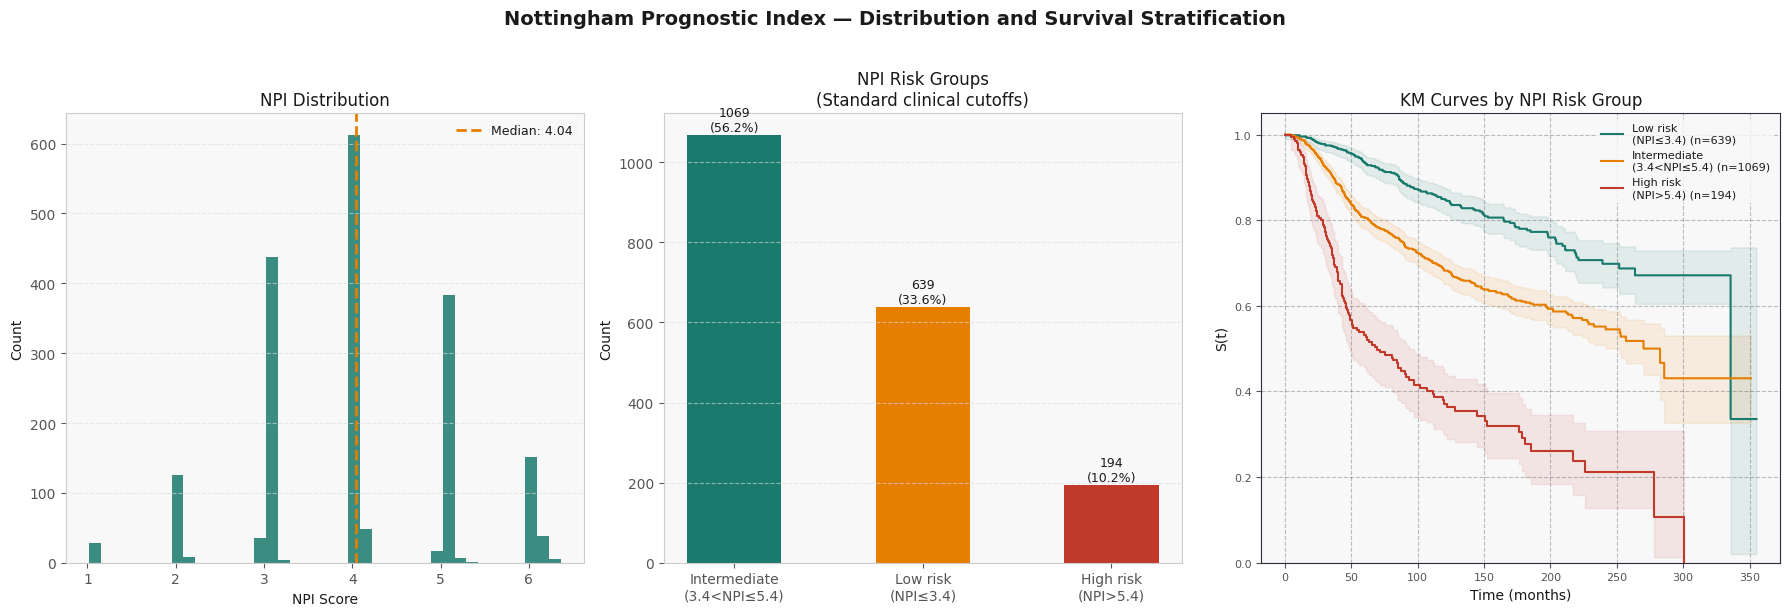

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('Nottingham Prognostic Index — Distribution and Survival Stratification',
             fontsize=14, fontweight='bold', color=COLOR_TEXT, y=1.02)

# NPI distribution
ax = axes[0]
ax.hist(df['nottingham_prognostic_index'].dropna(), bins=40,
        color=COLOR_PRESENT, edgecolor='none', alpha=0.85)
ax.axvline(df['nottingham_prognostic_index'].median(), color=COLOR_ACCENT,
           linewidth=2, linestyle='--',
           label=f"Median: {df['nottingham_prognostic_index'].median():.2f}")
ax.set_title('NPI Distribution', fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('NPI Score', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

# NPI risk groups — standard clinical cutoffs
# Low risk: NPI <= 3.4, Intermediate: 3.4-5.4, High: > 5.4
ax = axes[1]
df['npi_group'] = pd.cut(df['nottingham_prognostic_index'],
                          bins=[0, 3.4, 5.4, 100],
                          labels=['Low risk\n(NPI≤3.4)',
                                  'Intermediate\n(3.4<NPI≤5.4)',
                                  'High risk\n(NPI>5.4)'])
npi_counts = df['npi_group'].value_counts()
bars = ax.bar(npi_counts.index, npi_counts.values,
              color=[COLOR_PRESENT, COLOR_ACCENT, COLOR_MISSING],
              edgecolor='none', width=0.5)
for bar, val in zip(bars, npi_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val}\n({100*val/len(df):.1f}%)',
            ha='center', fontsize=9, color=COLOR_TEXT)
ax.set_title('NPI Risk Groups\n(Standard clinical cutoffs)', fontsize=12, color=COLOR_TEXT)
ax.set_ylabel('Count', fontsize=10)
ax.grid(axis='y')

# KM curves by NPI risk group
ax = axes[2]
npi_colors = [COLOR_PRESENT, COLOR_ACCENT, COLOR_MISSING]
for group, color in zip(['Low risk\n(NPI≤3.4)', 'Intermediate\n(3.4<NPI≤5.4)',
                          'High risk\n(NPI>5.4)'], npi_colors):
    mask = df['npi_group'] == group
    if mask.sum() > 0:
        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=df.loc[mask, 'overall_survival_months'],
            event_observed=df.loc[mask, 'event'],
            label=f'{group} (n={mask.sum()})'
        )
        kmf.plot_survival_function(ax=ax, ci_show=True,
                                   color=color, ci_alpha=0.1)

ax.set_title('KM Curves by NPI Risk Group', fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('Time (months)', fontsize=10)
ax.set_ylabel('S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, color='#2A2D3A')
ax.tick_params(colors=COLOR_SUBTEXT, labelsize=8)
ax.legend(fontsize=8, facecolor=COLOR_CARD, edgecolor='none', labelcolor=COLOR_TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

plt.tight_layout()
plt.show()

/var/folders/2y/hylb1v1n55b2675rzdhyt2b00000gn/T/ipykernel_27283/2229459353.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_group'] = (df['age_at_diagnosis'] > age_median).map(
/var/folders/2y/hylb1v1n55b2675rzdhyt2b00000gn/T/ipykernel_27283/2229459353.py:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['size_group'] = (df['tumor_size'] > size_median).map(
/var/folders/2y/hylb1v1n55b2675rzdhyt2b00000gn/T/ipykernel_27283/2229459353.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

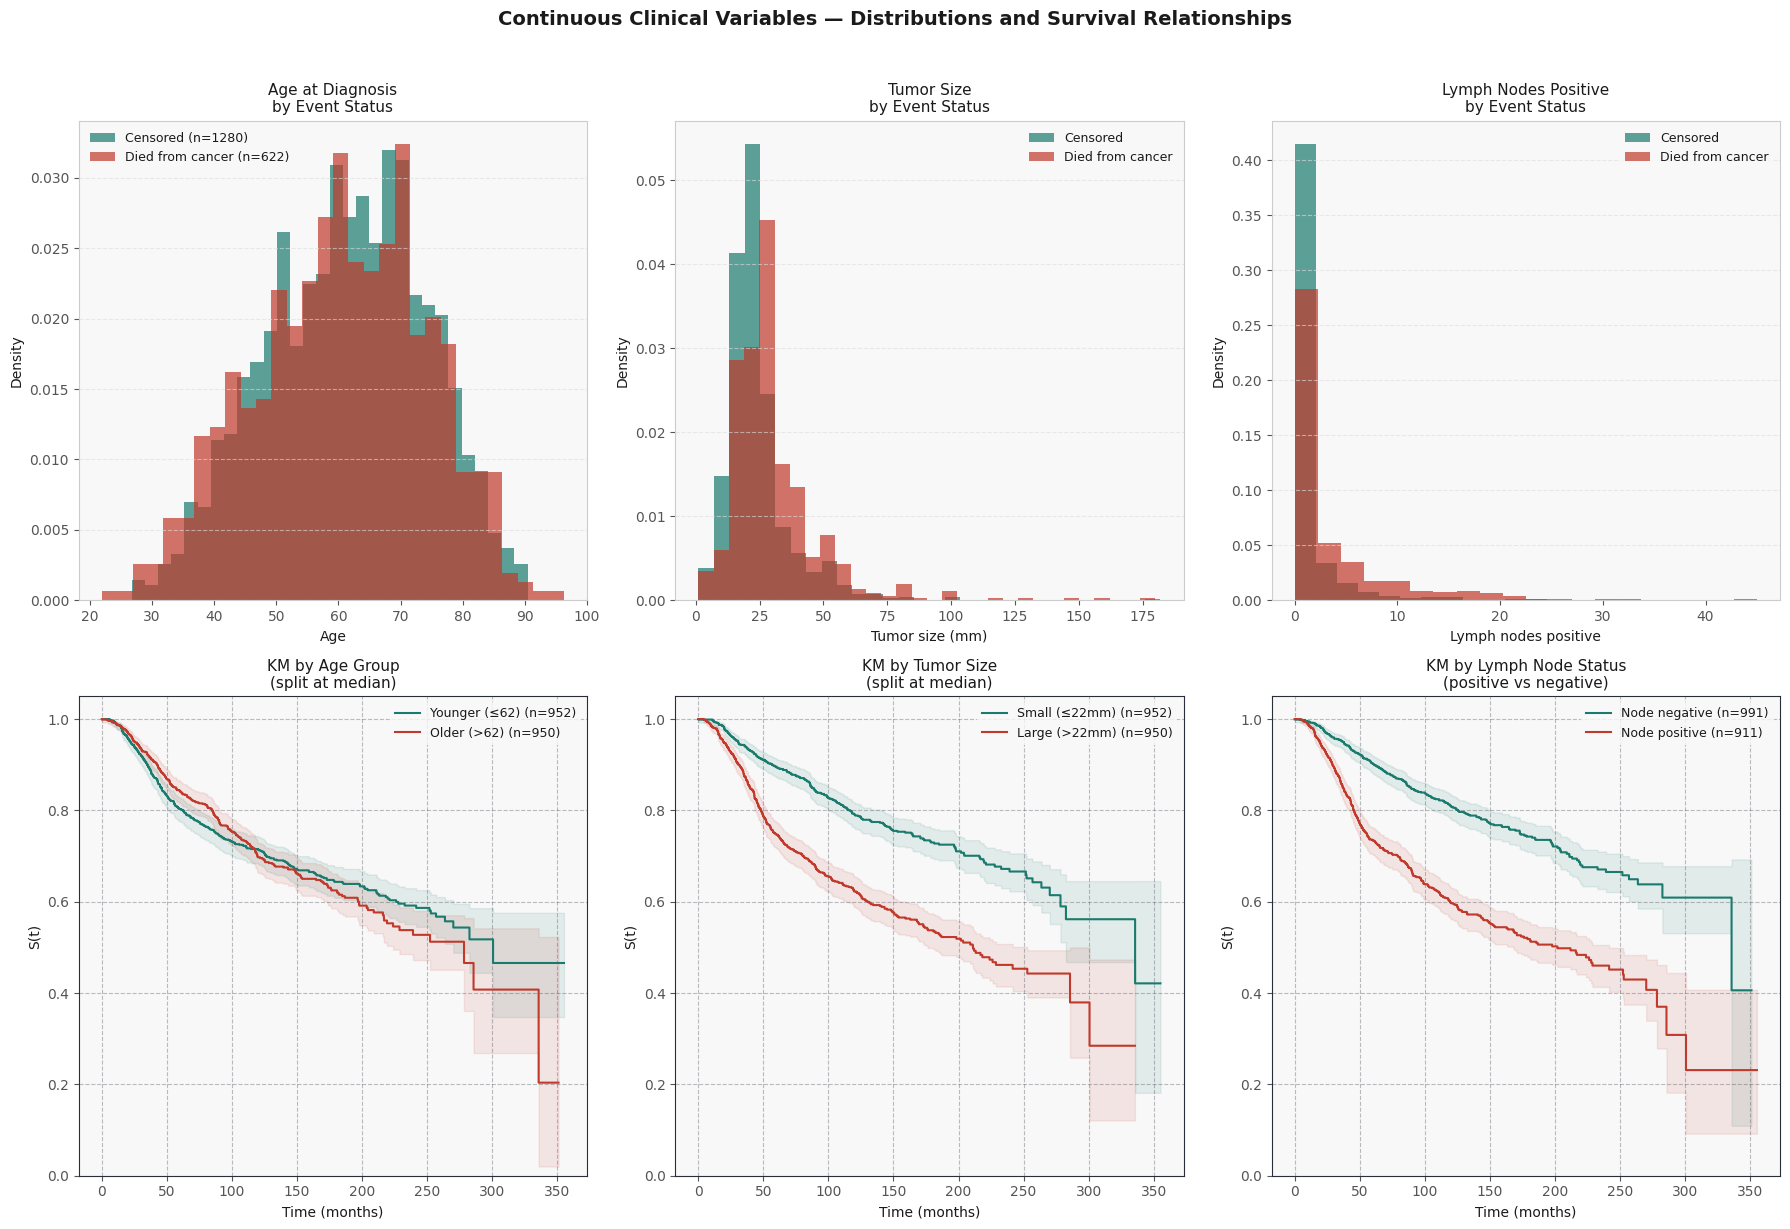

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('Continuous Clinical Variables — Distributions and Survival Relationships',
             fontsize=14, fontweight='bold', color=COLOR_TEXT, y=1.02)

# age distribution by event
ax = axes[0, 0]
ax.hist(df.loc[df['event']==0, 'age_at_diagnosis'], bins=30,
        alpha=0.7, color=COLOR_PRESENT, density=True,
        label=f'Censored (n={df["event"].eq(0).sum()})')
ax.hist(df.loc[df['event']==1, 'age_at_diagnosis'], bins=30,
        alpha=0.7, color=COLOR_MISSING, density=True,
        label=f'Died from cancer (n={df["event"].eq(1).sum()})')
ax.set_title('Age at Diagnosis\nby Event Status', fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Age', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

# tumor size distribution by event
ax = axes[0, 1]
ax.hist(df.loc[df['event']==0, 'tumor_size'], bins=30,
        alpha=0.7, color=COLOR_PRESENT, density=True,
        label='Censored')
ax.hist(df.loc[df['event']==1, 'tumor_size'], bins=30,
        alpha=0.7, color=COLOR_MISSING, density=True,
        label='Died from cancer')
ax.set_title('Tumor Size\nby Event Status', fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Tumor size (mm)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

# lymph nodes by event
ax = axes[0, 2]
ax.hist(df.loc[df['event']==0, 'lymph_nodes_examined_positive'], bins=20,
        alpha=0.7, color=COLOR_PRESENT, density=True,
        label='Censored')
ax.hist(df.loc[df['event']==1, 'lymph_nodes_examined_positive'], bins=20,
        alpha=0.7, color=COLOR_MISSING, density=True,
        label='Died from cancer')
ax.set_title('Lymph Nodes Positive\nby Event Status', fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Lymph nodes positive', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')

# age KM — split at median
ax = axes[1, 0]
age_median = df['age_at_diagnosis'].median()
df['age_group'] = (df['age_at_diagnosis'] > age_median).map(
    {True: f'Older (>{age_median:.0f})', False: f'Younger (≤{age_median:.0f})'})
for group, color in zip([f'Younger (≤{age_median:.0f})',
                          f'Older (>{age_median:.0f})'],
                         [COLOR_PRESENT, COLOR_MISSING]):
    mask = df['age_group'] == group
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, 'overall_survival_months'],
            df.loc[mask, 'event'], label=f'{group} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, ci_show=True,
                               color=color, ci_alpha=0.1)
ax.set_title('KM by Age Group\n(split at median)', fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Time (months)', fontsize=10)
ax.set_ylabel('S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, color='#2A2D3A')
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none', labelcolor=COLOR_TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

# tumor size KM — split at median
ax = axes[1, 1]
size_median = df['tumor_size'].median()
df['size_group'] = (df['tumor_size'] > size_median).map(
    {True: f'Large (>{size_median:.0f}mm)', False: f'Small (≤{size_median:.0f}mm)'})
for group, color in zip([f'Small (≤{size_median:.0f}mm)',
                          f'Large (>{size_median:.0f}mm)'],
                         [COLOR_PRESENT, COLOR_MISSING]):
    mask = df['size_group'] == group
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, 'overall_survival_months'],
            df.loc[mask, 'event'], label=f'{group} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, ci_show=True,
                               color=color, ci_alpha=0.1)
ax.set_title('KM by Tumor Size\n(split at median)', fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Time (months)', fontsize=10)
ax.set_ylabel('S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, color='#2A2D3A')
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none', labelcolor=COLOR_TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

# lymph nodes KM — node positive vs negative
ax = axes[1, 2]
df['node_group'] = (df['lymph_nodes_examined_positive'] > 0).map(
    {True: 'Node positive', False: 'Node negative'})
for group, color in zip(['Node negative', 'Node positive'],
                         [COLOR_PRESENT, COLOR_MISSING]):
    mask = df['node_group'] == group
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, 'overall_survival_months'],
            df.loc[mask, 'event'], label=f'{group} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, ci_show=True,
                               color=color, ci_alpha=0.1)
ax.set_title('KM by Lymph Node Status\n(positive vs negative)',
             fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Time (months)', fontsize=10)
ax.set_ylabel('S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, color='#2A2D3A')
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none', labelcolor=COLOR_TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

plt.tight_layout()
plt.show()

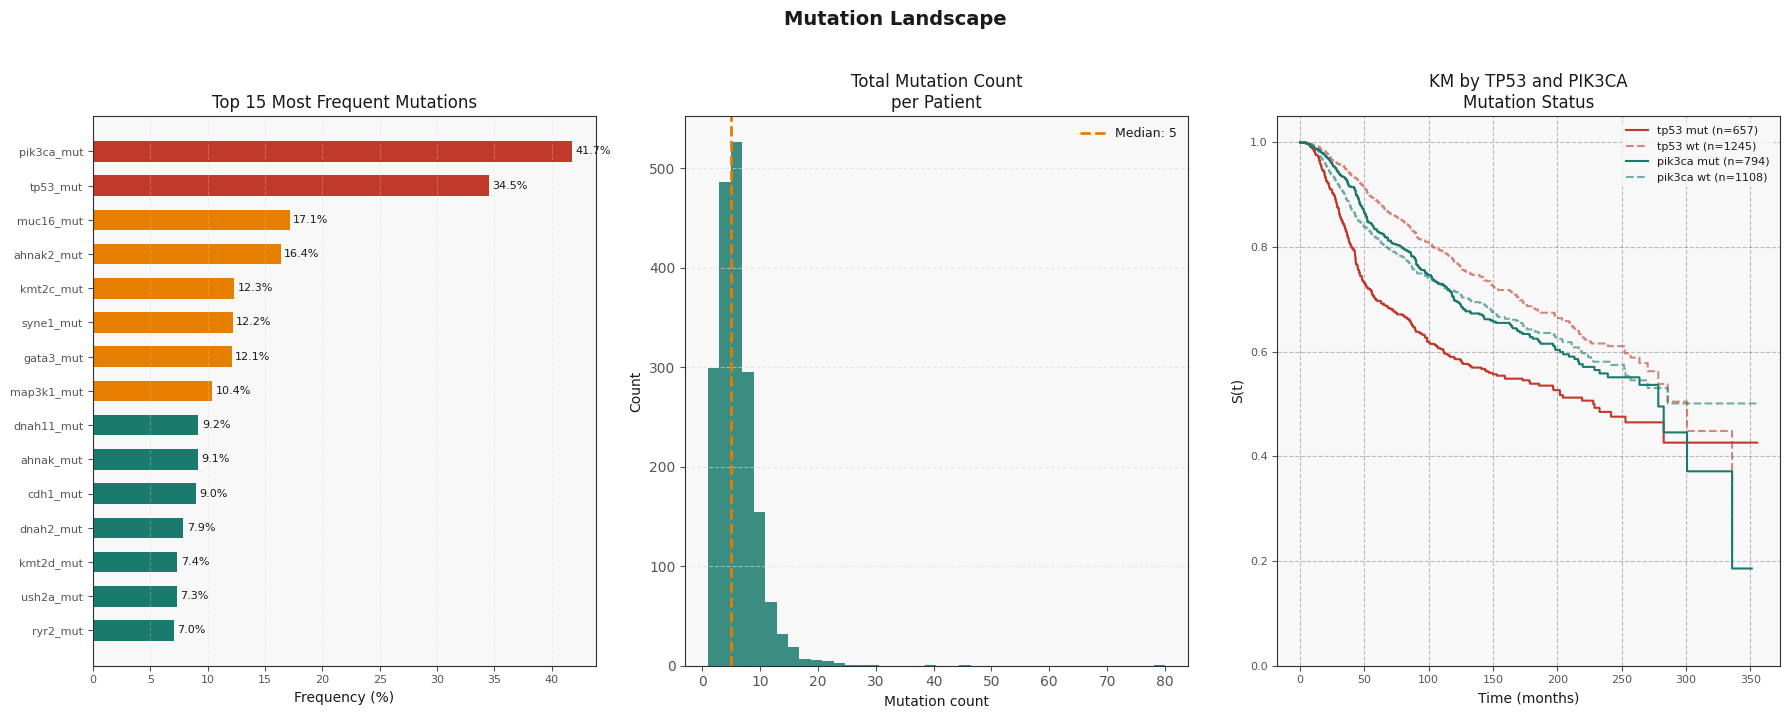

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('Mutation Landscape',
             fontsize=14, fontweight='bold', color=COLOR_TEXT, y=1.02)

# top 15 mutation frequencies
ax = axes[0]
mut_freq = df[mutation_cols].mean().sort_values(ascending=True).tail(15)
colors_mut = [COLOR_MISSING if v > 0.3 else COLOR_ACCENT if v > 0.1
              else COLOR_PRESENT for v in mut_freq.values]
ax.barh(mut_freq.index, mut_freq.values * 100,
        color=colors_mut, edgecolor='none', height=0.6)
for i, val in enumerate(mut_freq.values):
    ax.text(val * 100 + 0.3, i, f'{val*100:.1f}%',
            va='center', fontsize=8, color=COLOR_TEXT)
ax.set_title('Top 15 Most Frequent Mutations', fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('Frequency (%)', fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(colors=COLOR_SUBTEXT, labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

# mutation count distribution
ax = axes[1]
ax.hist(df['mutation_count'], bins=40,
        color=COLOR_PRESENT, edgecolor='none', alpha=0.85)
ax.axvline(df['mutation_count'].median(), color=COLOR_ACCENT,
           linewidth=2, linestyle='--',
           label=f"Median: {df['mutation_count'].median():.0f}")
ax.set_title('Total Mutation Count\nper Patient', fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('Mutation count', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')
ax.tick_params(colors=COLOR_SUBTEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

# KM curves for TP53 and PIK3CA mutations
ax = axes[2]
for gene, color, ls in [('tp53_mut', COLOR_MISSING, '-'),
                          ('pik3ca_mut', COLOR_PRESENT, '-')]:
    for mut_status, alpha in [(1, 1.0), (0, 0.6)]:
        mask = df[gene] == mut_status
        label = f'{gene.replace("_mut","")} {"mut" if mut_status else "wt"} (n={mask.sum()})'
        kmf = KaplanMeierFitter()
        kmf.fit(df.loc[mask, 'overall_survival_months'],
                df.loc[mask, 'event'], label=label)
        kmf.plot_survival_function(ax=ax, ci_show=False,
                                   color=color, alpha=alpha,
                                   linestyle=ls if mut_status else '--')

ax.set_title('KM by TP53 and PIK3CA\nMutation Status',
             fontsize=12, color=COLOR_TEXT)
ax.set_xlabel('Time (months)', fontsize=10)
ax.set_ylabel('S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, color='#2A2D3A')
ax.tick_params(colors=COLOR_SUBTEXT, labelsize=8)
ax.legend(fontsize=8, facecolor=COLOR_CARD,
          edgecolor='none', labelcolor=COLOR_TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

plt.tight_layout()
plt.show()

In [40]:
# ensure expression_cols only contains numeric float columns
expression_cols = [c for c in expression_cols if df[c].dtype == float]
print(f"Expression columns after dtype filter: {len(expression_cols)}")

Expression columns after dtype filter: 489


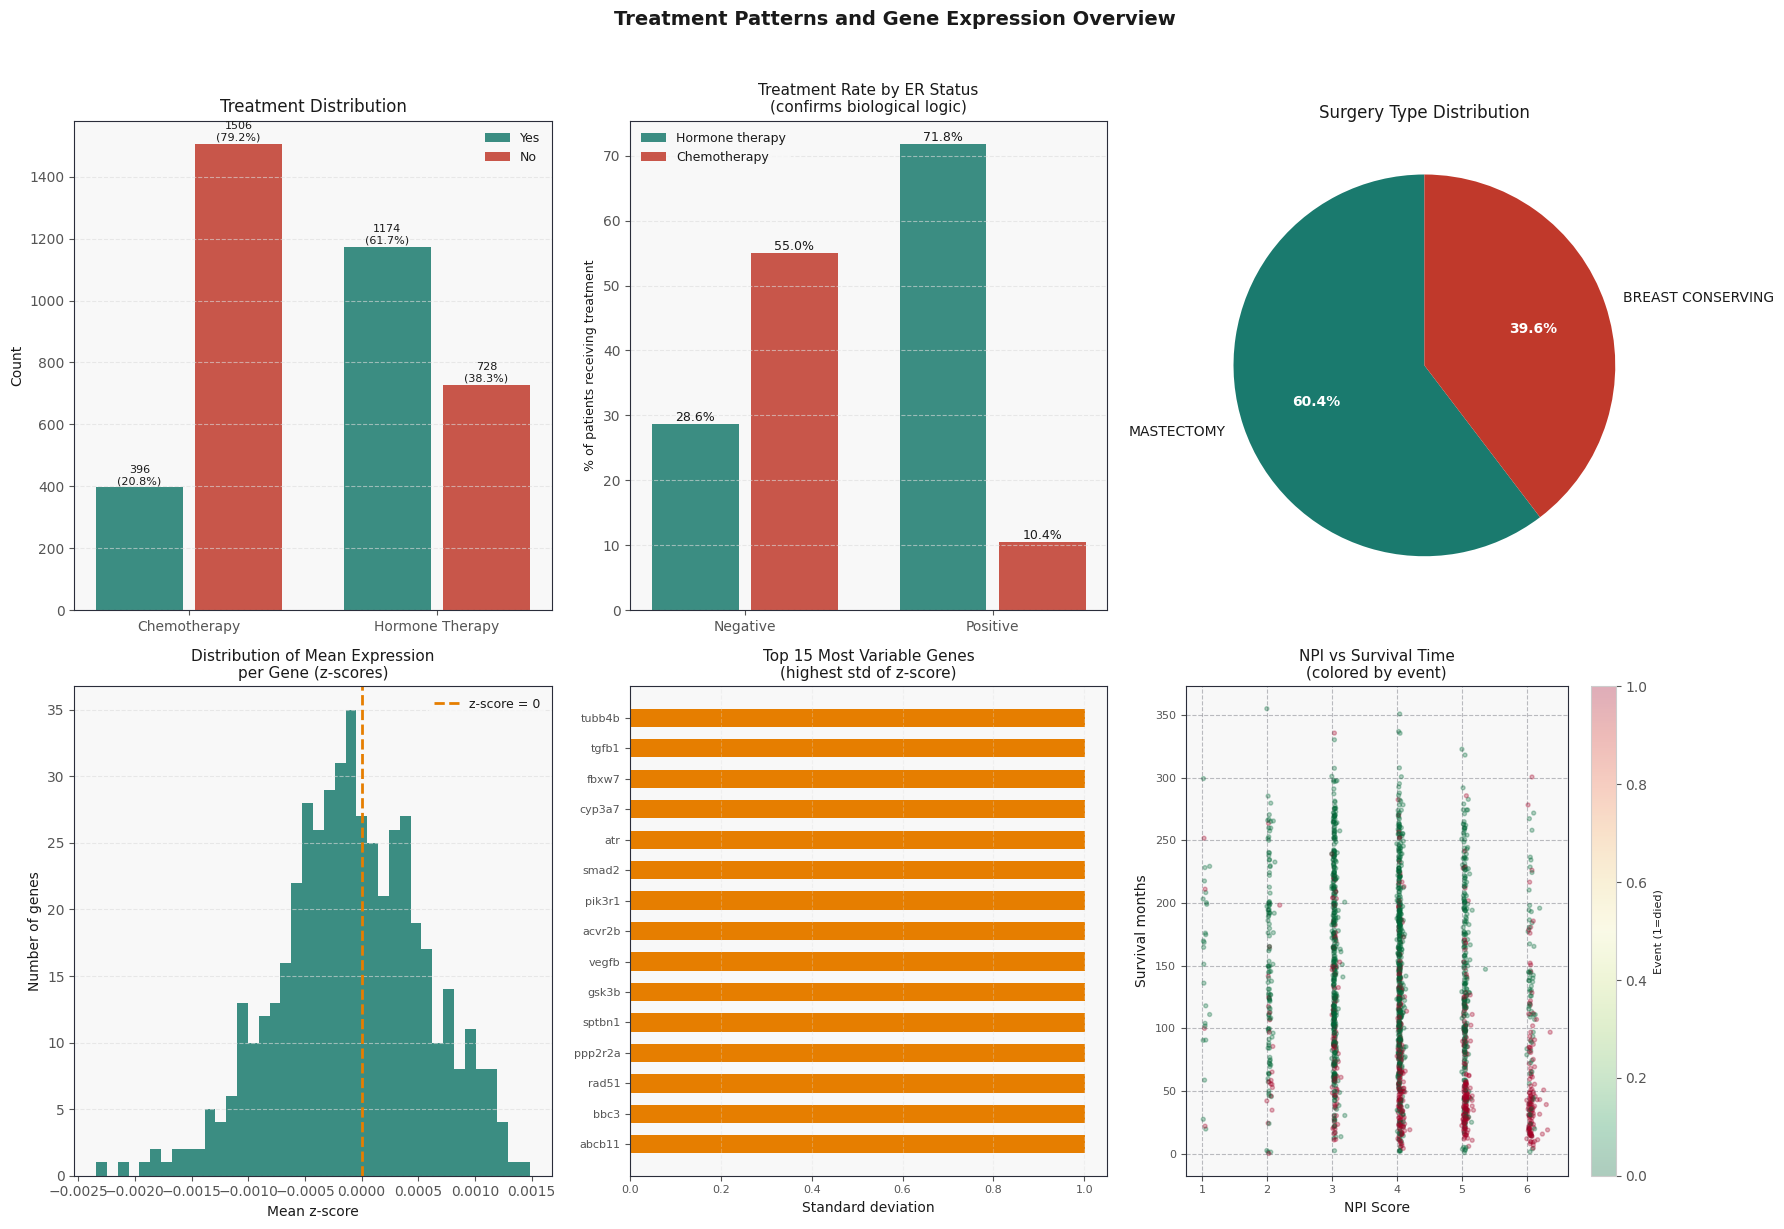

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor(COLOR_BG)
fig.suptitle('Treatment Patterns and Gene Expression Overview',
             fontsize=14, fontweight='bold', color=COLOR_TEXT, y=1.02)

# treatment distribution
ax = axes[0, 0]
treatments = ['chemotherapy', 'hormone_therapy']
treat_labels = ['Chemotherapy', 'Hormone Therapy']
treat_yes = [df[t].sum() for t in treatments]
treat_no  = [len(df) - y for y in treat_yes]
x = np.arange(len(treatments))
bars1 = ax.bar(x - 0.2, treat_yes, width=0.35,
               color=COLOR_PRESENT, alpha=0.85, label='Yes')
bars2 = ax.bar(x + 0.2, treat_no,  width=0.35,
               color=COLOR_MISSING, alpha=0.85, label='No')
for bar, val in zip(list(bars1)+list(bars2), treat_yes+treat_no):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{val}\n({100*val/len(df):.1f}%)',
            ha='center', fontsize=8, color=COLOR_TEXT)
ax.set_xticks(x)
ax.set_xticklabels(treat_labels)
ax.set_title('Treatment Distribution', fontsize=12, color=COLOR_TEXT)
ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')
ax.tick_params(colors=COLOR_SUBTEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

# treatment by ER status
ax = axes[0, 1]
er_hormone = df.groupby('er_status')['hormone_therapy'].mean() * 100
er_chemo   = df.groupby('er_status')['chemotherapy'].mean() * 100
x = np.arange(2)
bars1 = ax.bar(x - 0.2, er_hormone.values, width=0.35,
               color=COLOR_PRESENT, alpha=0.85, label='Hormone therapy')
bars2 = ax.bar(x + 0.2, er_chemo.values,   width=0.35,
               color=COLOR_MISSING, alpha=0.85, label='Chemotherapy')
for bar, val in zip(list(bars1)+list(bars2),
                    list(er_hormone.values)+list(er_chemo.values)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontsize=9, color=COLOR_TEXT)
ax.set_xticks(x)
ax.set_xticklabels(er_hormone.index)
ax.set_title('Treatment Rate by ER Status\n(confirms biological logic)',
             fontsize=11, color=COLOR_TEXT)
ax.set_ylabel('% of patients receiving treatment', fontsize=9)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')
ax.tick_params(colors=COLOR_SUBTEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

# surgery type distribution
ax = axes[0, 2]
surg_counts = df['type_of_breast_surgery'].value_counts()
wedges, texts, autotexts = ax.pie(
    surg_counts.values,
    labels=surg_counts.index,
    autopct='%1.1f%%',
    colors=[COLOR_PRESENT, COLOR_MISSING],
    startangle=90,
    textprops={'color': COLOR_TEXT, 'fontsize': 10}
)
for at in autotexts:
    at.set_color(COLOR_BG)
    at.set_fontweight('bold')
ax.set_title('Surgery Type Distribution', fontsize=12, color=COLOR_TEXT)

# gene expression — distribution of mean expression per gene
ax = axes[1, 0]
gene_means = df[expression_cols].mean()
ax.hist(gene_means, bins=40, color=COLOR_PRESENT,
        edgecolor='none', alpha=0.85)
ax.axvline(0, color=COLOR_ACCENT, linewidth=2,
           linestyle='--', label='z-score = 0')
ax.set_title('Distribution of Mean Expression\nper Gene (z-scores)',
             fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Mean z-score', fontsize=10)
ax.set_ylabel('Number of genes', fontsize=10)
ax.legend(fontsize=9, facecolor=COLOR_CARD, edgecolor='none')
ax.grid(axis='y')
ax.tick_params(colors=COLOR_SUBTEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

# top 15 most variable genes
ax = axes[1, 1]
gene_stds = df[expression_cols].std().sort_values(ascending=True).tail(15)
ax.barh(gene_stds.index, gene_stds.values,
        color=COLOR_ACCENT, edgecolor='none', height=0.6)
ax.set_title('Top 15 Most Variable Genes\n(highest std of z-score)',
             fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Standard deviation', fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(colors=COLOR_SUBTEXT, labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

# correlation of NPI with tumor size and lymph nodes
ax = axes[1, 2]
scatter = ax.scatter(df['nottingham_prognostic_index'],
                     df['overall_survival_months'],
                     c=df['event'],
                     cmap='RdYlGn_r',
                     alpha=0.3, s=8)
ax.set_title('NPI vs Survival Time\n(colored by event)',
             fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('NPI Score', fontsize=10)
ax.set_ylabel('Survival months', fontsize=10)
ax.grid(True, alpha=0.3, color='#2A2D3A')
ax.tick_params(colors=COLOR_SUBTEXT, labelsize=8)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Event (1=died)', color=COLOR_TEXT, fontsize=8)
cbar.ax.yaxis.set_tick_params(color=COLOR_SUBTEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2D3A')

plt.tight_layout()
plt.show()

# Layer 3 — Final Data Preparation for Modeling
## Step 1 — Categorical encoding


In [83]:
df_model = df.copy()
print(df_model.shape)

(1902, 687)


In [84]:
clinical_cols = [
    'age_at_diagnosis',
    'type_of_breast_surgery',
    'cancer_type_detailed',
    'cellularity',
    'cohort',
    'er_status',
    'neoplasm_histologic_grade',
    'her2_status',
    'tumor_size',
    'primary_tumor_laterality',
    'lymph_nodes_examined_positive',
    'nottingham_prognostic_index',
    'pr_status',
    'chemotherapy',
    'hormone_therapy',
    '3-gene_classifier_subtype',
    'mutation_count'
]

target_cols = [
    'overall_survival',
    'death_from_cancer',
    'event',
    'overall_survival_months'
]

In [85]:
# identify mutation and expression columns

mutation_cols = [c for c in df_model.columns if c.endswith('_mut')]

non_expression_cols = clinical_cols + mutation_cols + target_cols + ['patient_id']
expression_cols = [c for c in df_model.columns if c not in non_expression_cols]

print(f"Clinical columns: {len(clinical_cols)}")
print(f"Mutation columns: {len(mutation_cols)}")
print(f"Expression columns: {len(expression_cols)}")

Clinical columns: 17
Mutation columns: 173
Expression columns: 493


In [86]:
for col in mutation_cols:
    df_model[col] = df_model[col].apply(
        lambda x: 0 if str(x).strip() == '0' else 1
    ).astype(int)

print(df_model[mutation_cols].dtypes.value_counts())
print(df_model[mutation_cols[:5]].head())

int64    173
Name: count, dtype: int64
   pik3ca_mut  tp53_mut  muc16_mut  ahnak2_mut  kmt2c_mut
0           0         0          0           0          0
1           0         1          0           0          0
2           1         0          0           0          0
3           1         0          0           0          0
4           0         1          0           0          0


In [87]:
# filter rare mutation columns

mut_freq = df_model[mutation_cols].mean()

min_mut_freq = 0.01  # keep mutations present in at least 1% of patients

mutation_cols_filtered = mut_freq[mut_freq >= min_mut_freq].index.tolist()
rare_mutation_cols = mut_freq[mut_freq < min_mut_freq].index.tolist()

print(f"Original mutation columns: {len(mutation_cols)}")
print(f"Kept mutation columns: {len(mutation_cols_filtered)}")
print(f"Dropped rare mutation columns: {len(rare_mutation_cols)}")

Original mutation columns: 173
Kept mutation columns: 115
Dropped rare mutation columns: 58


In [88]:
# encode ordinal clinical variables

df_encoded = df_model.copy()

cellularity_map = {
    'Low': 0,
    'Moderate': 1,
    'High': 2
}

df_encoded['cellularity'] = df_encoded['cellularity'].map(cellularity_map)
df_encoded['neoplasm_histologic_grade'] = (
    df_encoded['neoplasm_histologic_grade']
    .astype(int)
)

print(df_encoded[['cellularity', 'neoplasm_histologic_grade']].head())

   cellularity  neoplasm_histologic_grade
0            2                          3
1            2                          3
2            2                          2
3            1                          2
4            2                          3


In [89]:
# one-hot encode nominal clinical variables

nominal_cols = [
    'type_of_breast_surgery',
    'cancer_type_detailed',
    'primary_tumor_laterality',
    'er_status',
    'her2_status',
    'pr_status',
    '3-gene_classifier_subtype'
]

df_encoded = pd.get_dummies(
    df_encoded,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)

print(df_encoded.shape)

(1902, 694)


In [90]:
# rebuild encoded clinical feature list

encoded_clinical_features = []

for col in df_encoded.columns:
    if (
        col in ['age_at_diagnosis',
                'cellularity',
                'neoplasm_histologic_grade',
                'tumor_size',
                'lymph_nodes_examined_positive',
                'nottingham_prognostic_index',
                'chemotherapy',
                'hormone_therapy',
                'mutation_count']
        or col.startswith('type_of_breast_surgery_')
        or col.startswith('cancer_type_detailed_')
        or col.startswith('primary_tumor_laterality_')
        or col.startswith('er_status_')
        or col.startswith('her2_status_')
        or col.startswith('pr_status_')
        or col.startswith('3-gene_classifier_subtype_')
    ):
        encoded_clinical_features.append(col)

print(f"Encoded clinical features: {len(encoded_clinical_features)}")
print(encoded_clinical_features)

Encoded clinical features: 23
['age_at_diagnosis', 'cellularity', 'chemotherapy', 'neoplasm_histologic_grade', 'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'tumor_size', 'type_of_breast_surgery_MASTECTOMY', 'cancer_type_detailed_Breast Invasive Ductal Carcinoma', 'cancer_type_detailed_Breast Invasive Lobular Carcinoma', 'cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma', 'cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma', 'cancer_type_detailed_Metaplastic Breast Cancer', 'primary_tumor_laterality_Right', 'er_status_Positive', 'her2_status_Positive', 'pr_status_Positive', '3-gene_classifier_subtype_ER+/HER2- Low Prolif', '3-gene_classifier_subtype_ER-/HER2-', '3-gene_classifier_subtype_HER2+', '3-gene_classifier_subtype_Unknown']


In [91]:
# define initial feature sets

genomic_features_full = expression_cols + mutation_cols_filtered
combined_features_full = encoded_clinical_features + genomic_features_full

print(f"Clinical features: {len(encoded_clinical_features)}")
print(f"Full genomic features: {len(genomic_features_full)}")
print(f"Full combined features: {len(combined_features_full)}")

Clinical features: 23
Full genomic features: 608
Full combined features: 631


In [92]:
# train/test split BEFORE expression feature selection

from sklearn.model_selection import train_test_split

X_full = df_encoded[combined_features_full]
y_time = df_encoded['overall_survival_months']
y_event = df_encoded['event']

X_train_full, X_test_full, time_train, time_test, event_train, event_test = train_test_split(
    X_full,
    y_time,
    y_event,
    test_size=0.25,
    random_state=42,
    stratify=y_event
)

print(f"Train patients: {len(X_train_full)}")
print(f"Test patients: {len(X_test_full)}")
print(f"Train event rate: {event_train.mean():.3f}")
print(f"Test event rate: {event_test.mean():.3f}")

Train patients: 1426
Test patients: 476
Train event rate: 0.327
Test event rate: 0.328


In [93]:
clinical_cols = clinical_cols + [
    'pam50_+_claudin-low_subtype',
    'inferred_menopausal_state',
    'integrative_cluster'
]

In [94]:
non_expression_cols = clinical_cols + mutation_cols + target_cols + ['patient_id']

expression_cols = [
    c for c in df_model.columns
    if c not in non_expression_cols
]

In [95]:
bad_expression_cols = [
    c for c in expression_cols
    if df_model[c].dtype == 'object'
]

print(bad_expression_cols)

[]


In [96]:
# select top expression genes using TRAINING SET ONLY

gene_vars_train = X_train_full[expression_cols].var().sort_values(ascending=False)

top_n_genes = 100
top_100_genes = gene_vars_train.head(top_n_genes).index.tolist()

print(f"Selected top expression genes: {len(top_100_genes)}")
print(top_100_genes[:20])

Selected top expression genes: 100
['ugt2b17', 'magea8', 'cyp3a7', 'taf4b', 'smad5', 'tubb4a', 'ugt2b15', 'mmp1', 'stab2', 'aff2', 'lipi', 'igf1', 'pik3ca', 'itgb3', 'lifr', 'rps6kb1', 'abcb1', 'cdkn2c', 'herc2', 'ryr2']


In [97]:
bad_expression_cols = [
    c for c in expression_cols
    if df_model[c].dtype == 'object'
]

print(bad_expression_cols)

[]


## Step 2 — Define three feature sets

In [98]:
clinical_features = encoded_clinical_features
genomic_features_filtered = top_100_genes + mutation_cols_filtered
combined_features_filtered = clinical_features + genomic_features_filtered

print(f"Clinical features: {len(clinical_features)}")
print(f"Filtered genomic features: {len(genomic_features_filtered)}")
print(f"Filtered combined features: {len(combined_features_filtered)}")

Clinical features: 23
Filtered genomic features: 215
Filtered combined features: 238


In [99]:
# create final train/test matrices

X_train_clinical = X_train_full[clinical_features]
X_test_clinical = X_test_full[clinical_features]

X_train_genomic = X_train_full[genomic_features_filtered]
X_test_genomic = X_test_full[genomic_features_filtered]

X_train_combined = X_train_full[combined_features_filtered]
X_test_combined = X_test_full[combined_features_filtered]

print("Clinical:", X_train_clinical.shape, X_test_clinical.shape)
print("Genomic:", X_train_genomic.shape, X_test_genomic.shape)
print("Combined:", X_train_combined.shape, X_test_combined.shape)

Clinical: (1426, 23) (476, 23)
Genomic: (1426, 215) (476, 215)
Combined: (1426, 238) (476, 238)


In [100]:
# optional scaling for Cox / Elastic Net / DeepSurv

from sklearn.preprocessing import StandardScaler

continuous_cols = [
    'age_at_diagnosis',
    'tumor_size',
    'lymph_nodes_examined_positive',
    'nottingham_prognostic_index',
    'mutation_count'
]

continuous_cols = [c for c in continuous_cols if c in X_train_combined.columns]

scaler = StandardScaler()

X_train_combined_scaled = X_train_combined.copy()
X_test_combined_scaled = X_test_combined.copy()

X_train_combined_scaled[continuous_cols] = scaler.fit_transform(
    X_train_combined[continuous_cols]
)

X_test_combined_scaled[continuous_cols] = scaler.transform(
    X_test_combined[continuous_cols]
)

print("Scaling complete.")

Scaling complete.


In [101]:
# tumor-stage sensitivity dataset

# based on my professor's suggested experiment.
# this requires keeping a pre-drop version of the dataframe where tumor_stage still exists.

df_stage = df_before_stage_drop[df_before_stage_drop['tumor_stage'].notna()].copy()

print(f"Patients with known tumor_stage: {len(df_stage)}")
print(df_stage['tumor_stage'].value_counts().sort_index())

Patients with known tumor_stage: 1402
tumor_stage
0.0      4
1.0    474
2.0    800
3.0    115
4.0      9
Name: count, dtype: int64


In [102]:
# save processed dataframe
df_encoded.to_csv("../data/METABRIC_processed_encoded.csv", index=False)

# save all important preprocessing/modeling objects
preprocessing_objects = {

    # -----------------------------
    # raw / processed dataframes
    # -----------------------------
    'df_model': df_model,
    'df_encoded': df_encoded,
    'df_stage': df_stage,

    # -----------------------------
    # target definitions
    # -----------------------------
    'target_cols': target_cols,
    'time_col': 'overall_survival_months',
    'event_col': 'event',

    # -----------------------------
    # feature groups
    # -----------------------------
    'clinical_cols': clinical_cols,
    'mutation_cols': mutation_cols,
    'mutation_cols_filtered': mutation_cols_filtered,
    'rare_mutation_cols': rare_mutation_cols,
    'expression_cols': expression_cols,
    'top_100_genes': top_100_genes,

    # -----------------------------
    # final modeling feature sets
    # -----------------------------
    'clinical_features': clinical_features,
    'genomic_features': genomic_features_full,
    'combined_features': combined_features_full,

    'genomic_features_filtered': genomic_features_filtered,
    'combined_features_filtered': combined_features_filtered,

    # -----------------------------
    # train/test splits
    # -----------------------------
    'X_train_clinical': X_train_clinical,
    'X_test_clinical': X_test_clinical,

    'X_train_genomic': X_train_genomic,
    'X_test_genomic': X_test_genomic,

    'X_train_combined': X_train_combined,
    'X_test_combined': X_test_combined,

    'X_train_combined_scaled': X_train_combined_scaled,
    'X_test_combined_scaled': X_test_combined_scaled,

    # -----------------------------
    # survival targets
    # -----------------------------
    'time_train': time_train,
    'time_test': time_test,

    'event_train': event_train,
    'event_test': event_test,

    # -----------------------------
    # preprocessing objects
    # -----------------------------
    'scaler': scaler,

    # -----------------------------
    # metadata / diagnostics
    # -----------------------------
    'n_patients': len(df_encoded),
    'n_clinical_features': len(clinical_features),
    'n_expression_features': len(expression_cols),
    'n_mutation_features': len(mutation_cols_filtered),
    'n_combined_features_filtered': len(combined_features_filtered),

    'train_event_rate': float(event_train.mean()),
    'test_event_rate': float(event_test.mean())
}

# save pickle
with open("../data/preprocessing_objects.pkl", "wb") as f:
    pickle.dump(preprocessing_objects, f)

print("Saved successfully.")
print(f"Processed encoded dataframe shape: {df_encoded.shape}")
print(f"Clinical features: {len(clinical_features)}")
print(f"Filtered genomic features: {len(genomic_features_filtered)}")
print(f"Filtered combined features: {len(combined_features_filtered)}")

Saved successfully.
Processed encoded dataframe shape: (1902, 694)
Clinical features: 23
Filtered genomic features: 215
Filtered combined features: 238
